Vanessa Aidee Lugo Avalos 6AM1

# Librerías.
Se importan las librerías necesarias para manipulación de datos, visualización, separación del conjunto de entrenamiento y del conjunto de prueba, así como entrenamiento del modelo y métricas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from scipy.spatial.distance import cdist
from sklearn.linear_model import LogisticRegression
import seaborn as sns

# Descarga del conjunto de datos.
Se hace la descarga de datos directamente desde su URL.

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# Carga del conjunto de datos.
Se cargan los conjuntos de datos definiendo que estan separados por ';'

In [4]:
df = pd.read_csv(url, sep = ';')

# Visualización del conjunto de datos.
Se visualizan los datos, los cuales contienene propiedades químicas y una evaluación sensorial a una variante roja del vino portugués "Vinho Verde". De esta manera, se intenta predecir la calidad del vino según sus propiedades químicas.

In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Asignación de variables dependiente e independientes.
Se asigna como variable dependiente a la calidad del vino, y el restante son las variables independientes.

In [6]:
X = df.drop(columns=['quality'])
y = df['quality']

# Conversión a clasificación binaria.
Se establece que el vino es "bueno" si la calidad es mayor o igual a 6, y es "malo" en caso contrario.

In [7]:
y = (y >= 6).astype(int)

# Clase para la red neuronal de función de base radial con distancia euclidiana.
Una red neuronal de base radial (RBF) utiliza la base radial como función de activación. Cada una de estas neuronas RBF tiene un centro y mide la proximidad de la entrada a dicho centro. Estas redes cuentan con una capa de entrada, una capa ouclta donde aplica una función de base radial a las entradas que recibe, y una capa de salida donde cada neurona de esta capa calcula una suma ponderada de las salidas de la capa oculta, lo que da como resultado la salida final. La salida de "y" es una combinación lineal de funciones de base radial, la cual esta dada por:
$$y (x) = \sum_{i=1}^n w_i\sigma(||x-c_i||)$$   
Donde:  
$x$: Entrada del vector.   
$n$: Cantidad de neuronas.  
$c_i$: Centros de la función de base radial.   
$||x - c_i||$: Distancia euclidiana entre la entrada del vector y el centro.   
$\sigma$: Función de base radial, generalmente se usa la función gaussiana.   
$$\sigma (r) = mi^{-\beta r^2}$$ 

In [8]:
class Red_Neuronal_Radial: #Se define la clase de la red neuronal
    def __init__(self, num_centers = 10, sigma = 1.0): 
        self.num_centers = num_centers #Cantidad de centros
        self.sigma = sigma #Valor de sigma
        self.centers = None #Coordenadas de los centros
        self.model = LogisticRegression() #Se utiliza Regresión logistica para la capa de salida

    def _rbf_kernel(self, X, centers): #Método para calcular transformaciones matemáticas
        return np.exp(-cdist(X, centers, 'sqeuclidean')/(2* self.sigma**2)) #Matriz de distancias euclidianas

    def fit(self, X, y): #Método para entrenar el modelo
        indices = np.random.choice(len(X), self.num_centers, replace = False) #Se seleccionan números al azar como índices
        self.centers = X[indices] #Se establecen los centros
        X_rbf = self._rbf_kernel(X, self.centers) #Transforma los datos de entrenamiento según sus distancias
        self.model.fit(X_rbf, y) #Se entrena la regresión logística

    def predict(self, X): #Método para las predicciones
        X_rbf = self._rbf_kernel(X, self.centers) #Se transforman los datos usando los centros
        return self.model.predict(X_rbf) #Se obtienen  las predicciones

    def decision_function(self, X): #Método para el resultado final
        X_rbf = self._rbf_kernel(X, self.centers) #Se transforman los datos al espacio de la red neuronal
        return self.model.decision_function(X_rbf) #Retorna el resultado final

# Combinaciones
Se hace una función llamada "combinaciones" para establecer los tamaños de los conjuntos de prueba y entrenamiento, la cantidad de centros y el valor de sigma para entrenar el modelo, de manera que se hagan todas las posibles combinaciones y se guarden los resultados. Esta función recibe como paramétros a las variables independientes y la variable dependiente.
Se usa la función train_test_split() dentro de un ciclo for para que itere con tres conjuntos: 
1. 70% entrenamiento y 30% prueba.
2. 80% entrenamiento y 20% prueba.
3. 90% entrenamiento y 10% prueba.
Después, se usa la clase de Red_Neuronal_Radial antes definida dentro de un for, de manera que queda un for anidado, para probar con las combinaciones requeridas. Esta clase recibirá como paramétros la cantidad de centros y los valores para sigma:
1. Números de centros: 5, 15, 20, 25, 30
2. Valores de sigma: 0.1, 0.5, 2.0, 5.0

Así mismo, se calcula la precisión de cada combinación. Esto se hace mediante la siguiente fórmula: 
$$precisión (accuracy) = \frac{\text{predicciones correctas}}{\text{todas las predicciones}}$$   

Se calcula la matriz de confusión.
Se realiza la curva de Característica de funcionamiento del receptor (ROC) y el valor del área bajo la curva (AUC). La curva ROC evalúa el rendimiento de un modelo de casificación binaria de manera que se grafican la tasa de verdaderos positivos contra la tasa de falsos negativos en diferentes umbrales. Mientras que AUC mide la capacidad del modelo para distinguir entre clases, donde un valor de 0 a 0.5 significa un modelo peor que el azar, un valor de 0.5 significa un modelo de clasificaciión aleatorio, y un valor de 1 es un modelo perfecto.   
Se agregan variables vacias para almacenar el mejor valor de AUC y de precisión y diccionarios vacíos para indicar con que combinaciones se obtienen estos valores máximos con la finalidad de observar los mejores parámetros para el modelo.
Para el calculo de la mejor precisión y el mejor AUC, solo se agregan condicionales que comparan los valores, y si en caso de que sea mayor se guargan los paramétros en los diccionarios.

In [11]:
def combinaciones(X, y):
    pruebas = [0.3, 0.2, 0.1] #Se asignan los tamaños de prueba 
    centros = [5, 15, 20, 25, 30] #Se asigna la cantidad de centros
    sigmas = [0.1, 0.5, 2.0, 5.0] #Se establecen los valores para sigma

    mejor_auc = 0 #Se inicializa una variable para el mejor valor de AUC
    mejor_acc = 0 #Mejor valor de precisión
    parametros_acc = {} #Se establece un diccionario vacio la combinación de la mejor precisión
    parametros_auc = {} #Se establece un diccionario vacio la combinación del mejor AUC
    
    for test_size in pruebas: #Se realiza ciclo para los tamaños de conjunto de prueba
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=7)
        print(f'Tamaño del conjunto de prueba: {test_size}')
        
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        for num_centers in centros: #Se realiza ciclo para la cantidad de centros
            print(f'Cantidad de centros: {num_centers}')
            for sigma in sigmas: #Se realiza ciclo para los valores de sigma
                print(f'Valor de sigma: {sigma}')
                rbf = Red_Neuronal_Radial(num_centers=num_centers, sigma=sigma)
                rbf.fit(X_train, y_train) 
                
                y_pred = rbf.predict(X_test) #Se ccalculan los valores de y predicha
                print('Valores de predicción para y:')
                print(y_pred)
                
                accuracy = accuracy_score(y_test, y_pred) #Se calcula la precisión del modelo
                print(f'Precisión del modelo: {accuracy}')
                
                conf_matrix = confusion_matrix(y_test, y_pred) #Se calcula matriz de confusión
                plt.figure(figsize = (6,4))
                sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'coolwarm', 
                annot_kws = {'size': 14}, xticklabels = ['Baja calidad', 'Buena calidad'], #Se grafica la matriz de confusión
                yticklabels = ['Baja calidad', 'Buena calidad'])
                plt.xlabel('predicho')
                plt.ylabel('Real')
                plt.title('Matriz de confusión')
                plt.show()

                y_scores = rbf.decision_function(X_test) #
                fpr, tpr, _ = roc_curve(y_test, y_scores)
                roc_auc = auc(fpr, tpr)

                plt.figure(figsize = (6, 4)) #roc
                plt.plot(fpr, tpr, color = 'blue', label = f'ROC curve (AUC = {roc_auc})')
                plt.plot([0, 1], [0,1], linestyle = '--', color = 'gray')
                plt.xlabel('Tasa de Falsos Positivos')
                plt.ylabel('Tasa de verdaderos positivos')
                plt.title('Curva ROC')
                plt.legend()
                plt.show()

                if accuracy > mejor_acc: #Se establece condicional para guardar la mejor precisión
                    mejor_acc = accuracy
                    params_mejor_acc = {'test_size': test_size, 'centros': num_centers, 'sigma': sigma}

                if roc_auc > mejor_auc:
                    mejor_auc = roc_auc
                    params_mejor_auc = {'test_size': test_size, 'centros': num_centers, 'sigma': sigma}
    
    return mejor_acc, params_mejor_acc, mejor_auc, params_mejor_auc

# Evaluación
Se muestra la salida de todas las posibles combinaciones para la red neuronal junto con sus métricas. Se obtiene la mayor precisión y el mejor valor de AUC.

Tamaño del conjunto de prueba: 0.3
Cantidad de centros: 5
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 

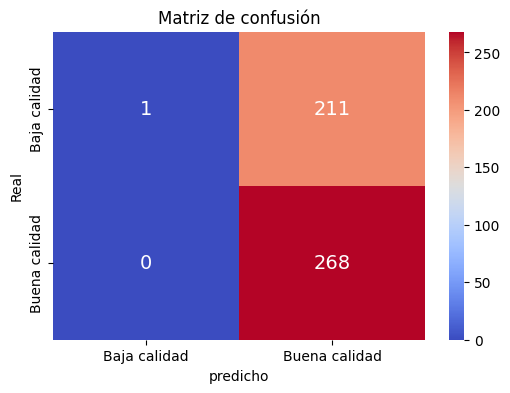

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

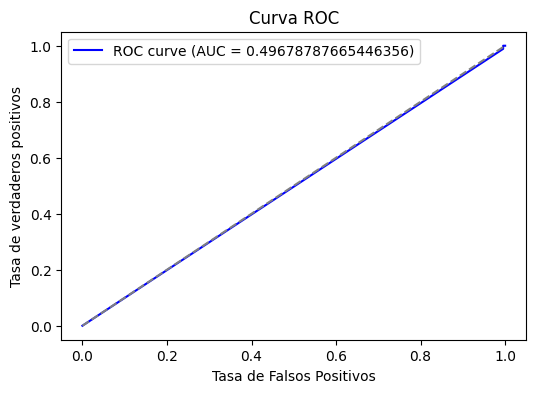

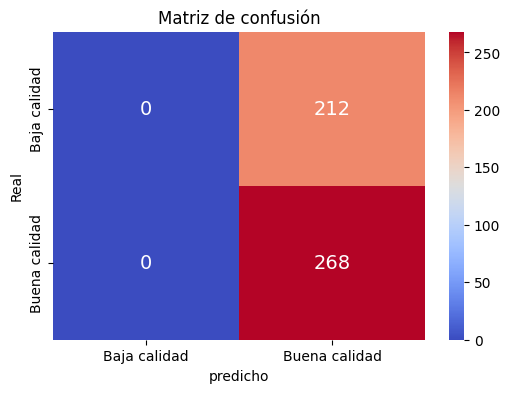

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 0 1 1 1 1 1 0 0 1 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1
 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 1 0 0 0 0 1 1 1 1 1 1 0 1 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0
 0 1 0 0 0 1 1 0 1 0 0 1 0 1 1 1 1 0 0 0 1 1 0 1 0 1 1 1 1 0 0 0 1 1 1 1 0
 1 1 0 0 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 1
 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 0 1 0 0 1 0 1 1 1 0 0 1 1 0 0 1 1 1 0 1 0
 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0
 0 0 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 0 1 0 1 0
 0 1 1 0 0 0 1 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 0 1 1 1 1 0
 1 0 1 1 0 1 0 1 1 1 0 1 0 1 0 1 0 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1
 0 0 1 0 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1

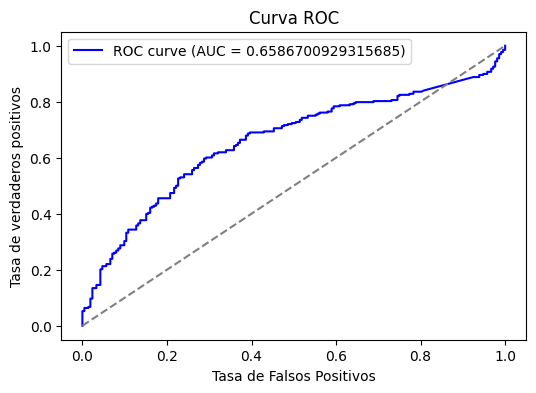

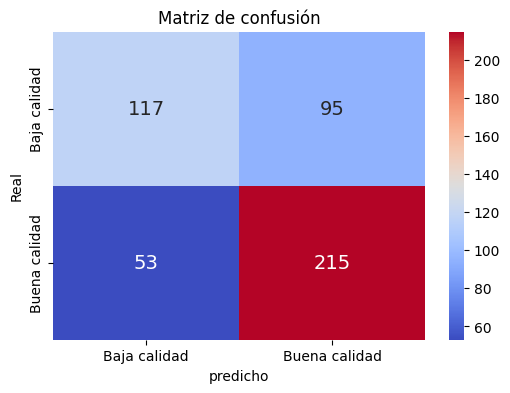

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 0 0 1 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 1 0 1 0 0 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 0 1 1 0 1 0 1 0 1 0 1 1 1 1
 0 1 1 1 0 1 0 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 1 1
 0 1 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0
 1 1 0 1 1 1 0 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 1 0
 1 1 1 0 1 0 1 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1
 0 0 1 1 0 1 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 0
 1 1 0 1 1 0 1 0 0 0 1 1 0 1 1 0 1 1 0 1 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 0 1
 1 0 0 1 0 1 1 1 0 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 1
 1 1 1 0 0 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 1 1 0 1 1 0 0 0 1 1
 1 0 0 0 1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 0 0 0 1 0 1 1 0 0 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1

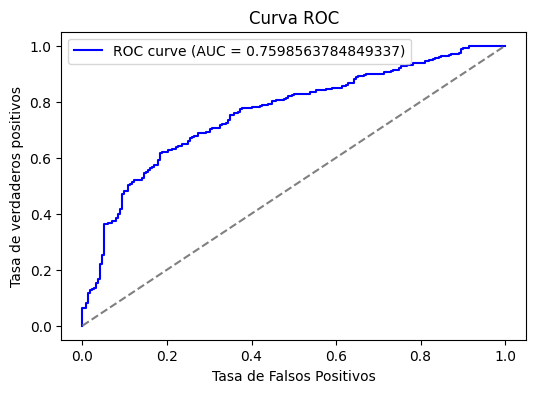

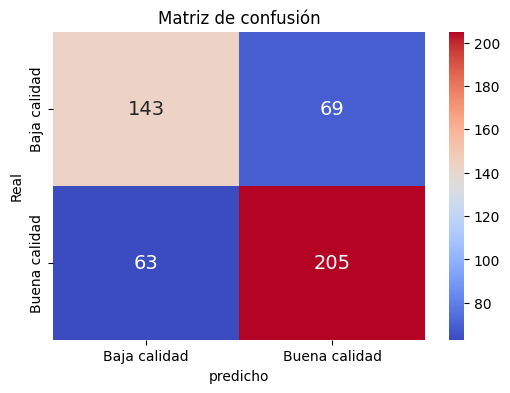

Cantidad de centros: 15
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1

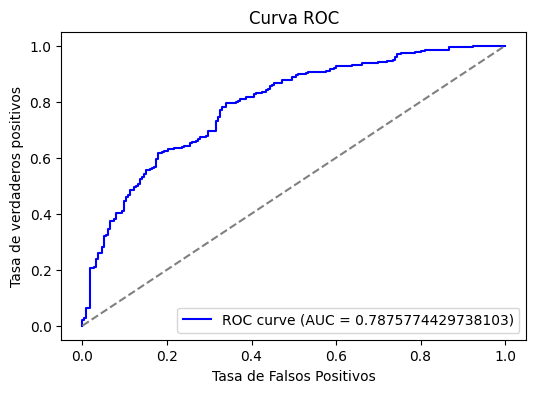

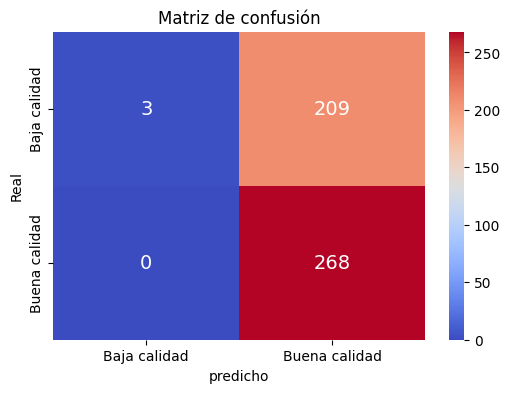

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

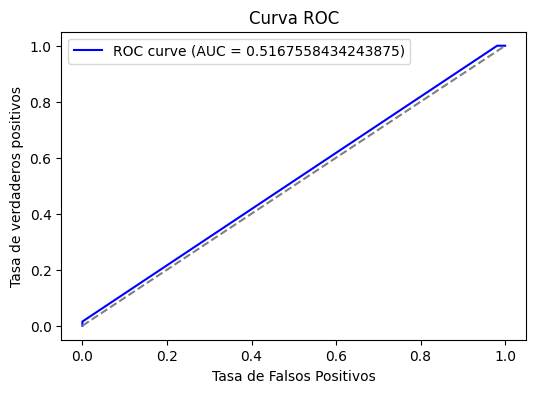

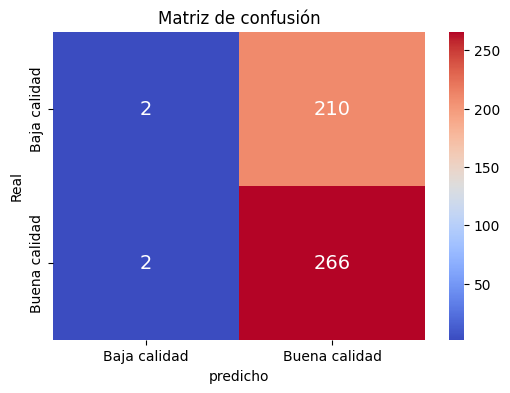

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 0 0 0 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0
 1 1 0 1 1 0 1 0 0 0 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 0 1 1 1 1 0 1 1 1 1 1 0
 1 1 1 0 0 0 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 1 1 0 1 1 0 0 0 1 1
 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 0 0 1 1 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1

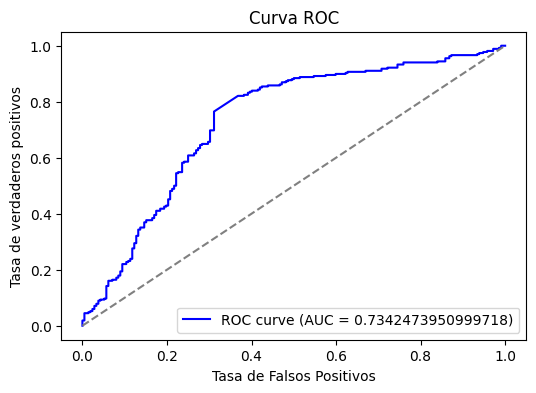

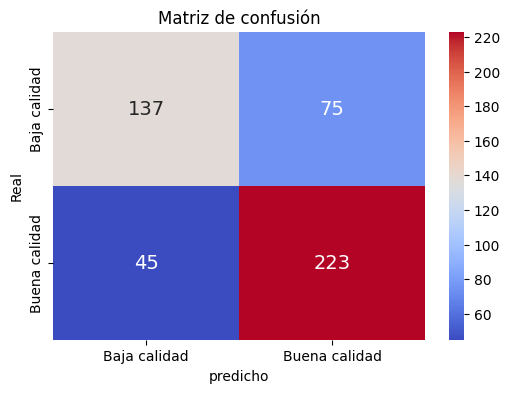

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 0 1 0 0 1
 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 0 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0
 1 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 1 1
 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 0 1
 1 0 0 1 0 1 1 0 0 1 0 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 1
 1 1 1 0 0 0 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 0 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1 0 1 0 1
 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1

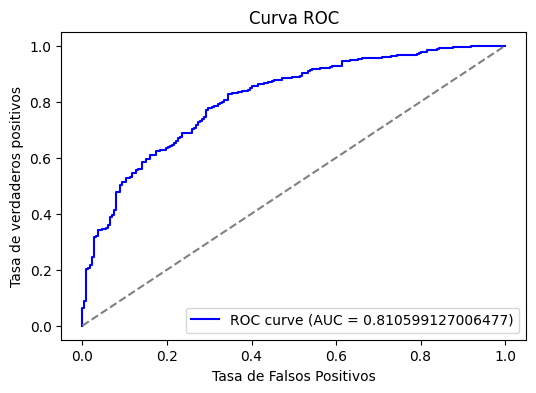

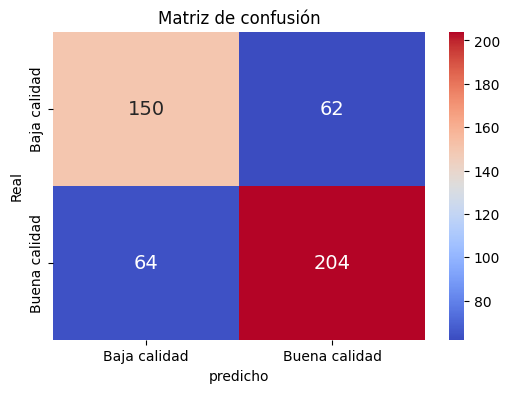

Cantidad de centros: 20
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1

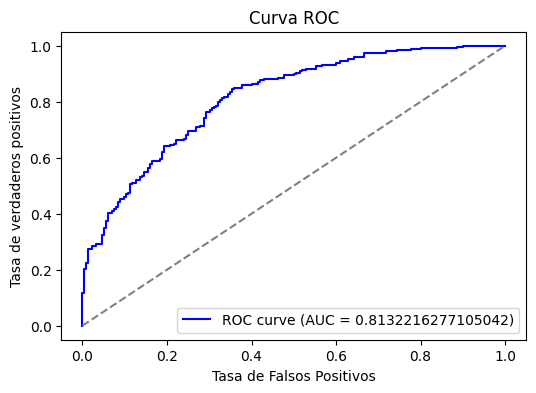

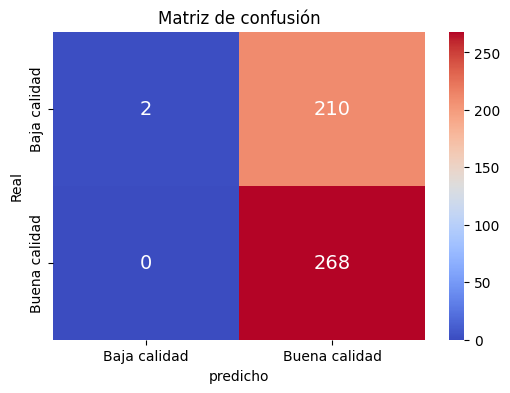

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

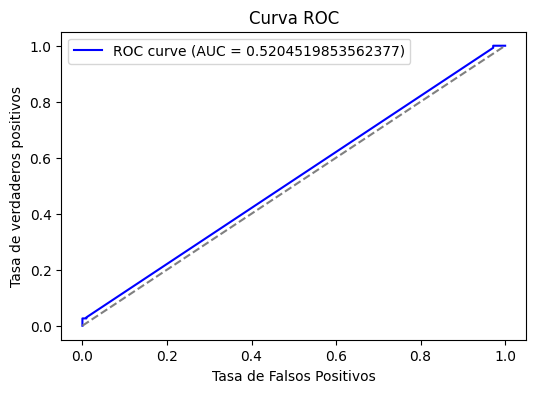

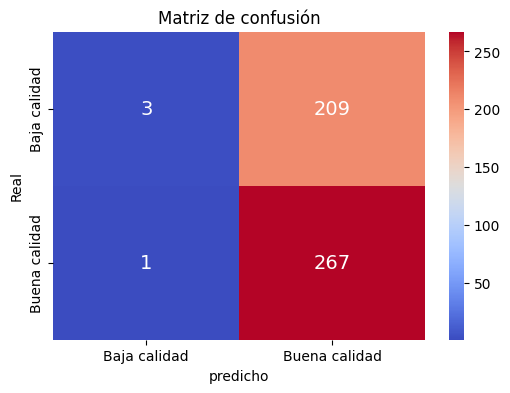

Valor de sigma: 2.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 0 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 1 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 0 1 1 0 1 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0
 0 1 0 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 1 0 0 0 0 1 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 0 0 0 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 0
 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1

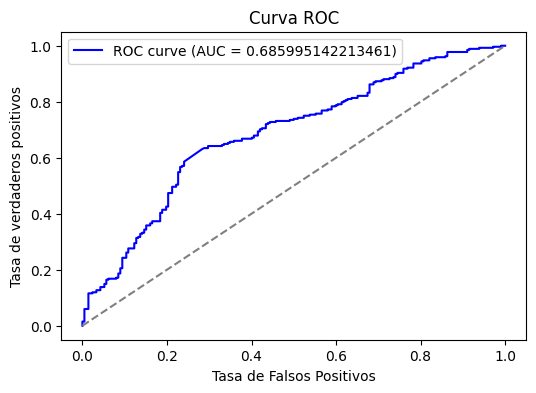

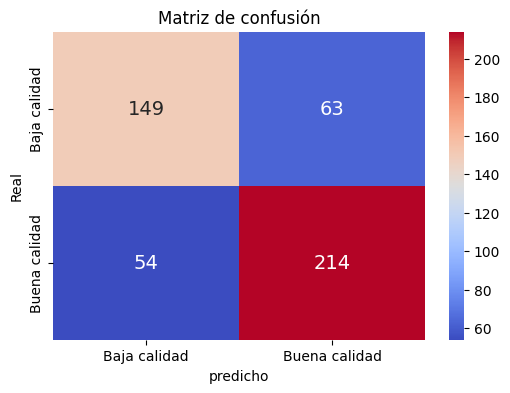

Valor de sigma: 5.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1
 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0
 1 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0 1 0 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 1 0 0 0 1 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1
 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 1
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 1 1 0 0 0 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 1 1
 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 1 1 1 1 0 1 1 1 1 1
 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1

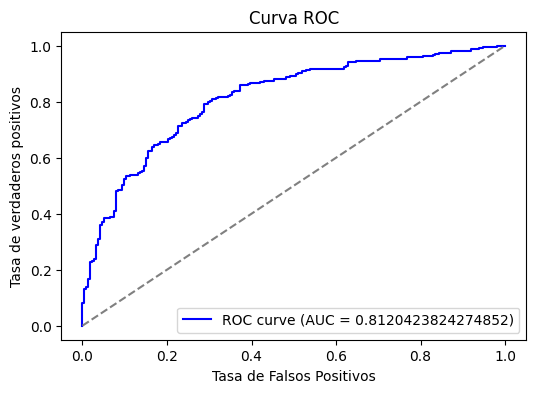

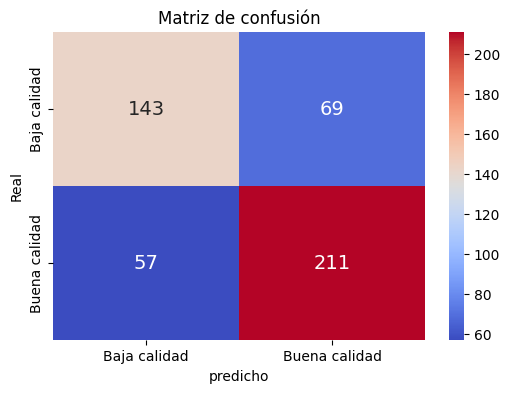

Cantidad de centros: 25
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1

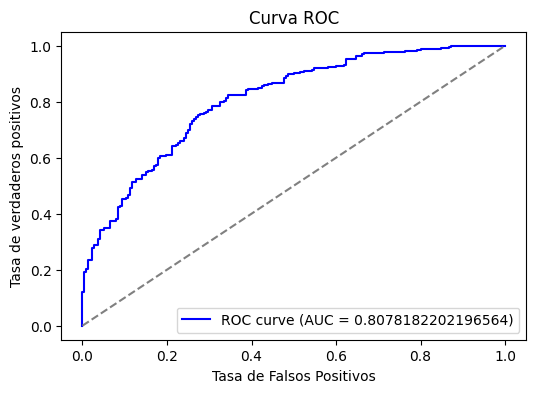

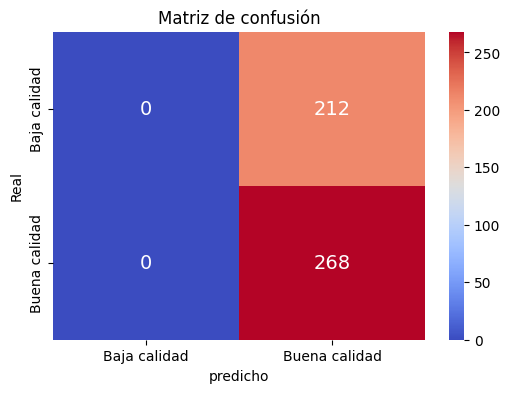

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

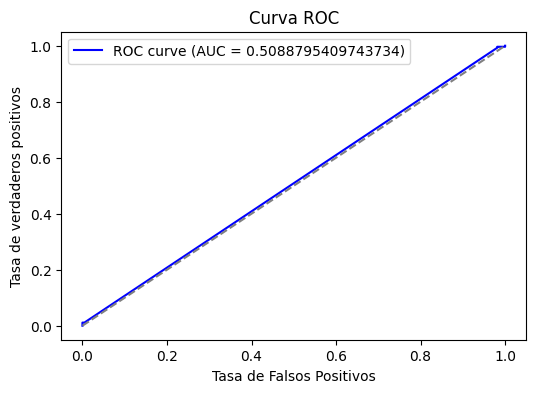

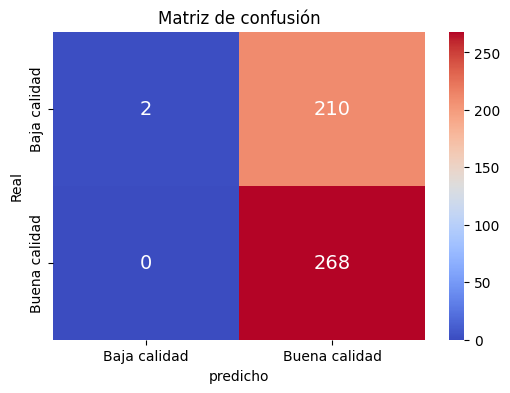

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 0 0 1 0 0 1 0 1 1 0
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 1 0 0 0 1 1 1 0 1 1 1 1 0 1 0
 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 0
 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 1
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 0 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 0 1
 0 0 0 0 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1

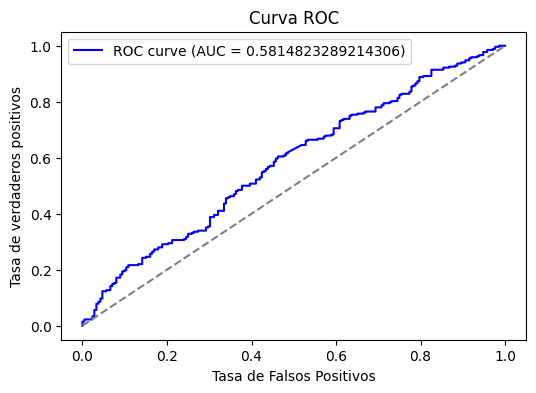

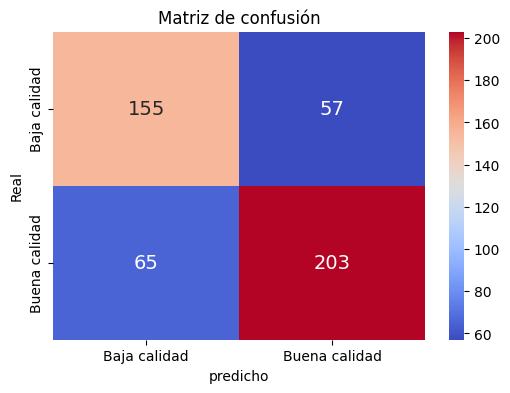

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 1
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 0 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1

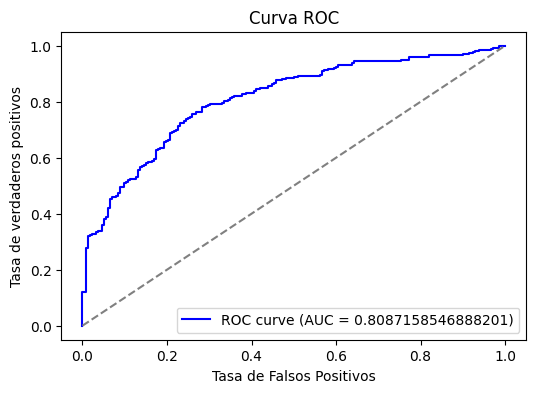

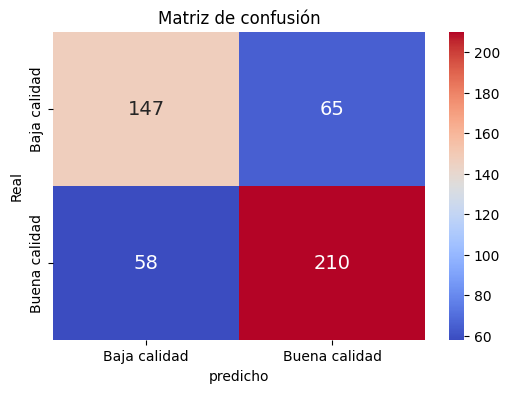

Cantidad de centros: 30
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1

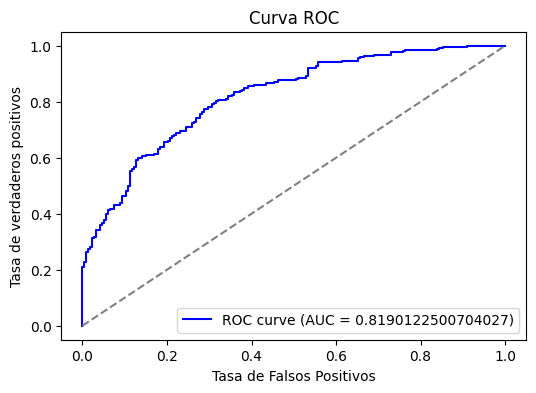

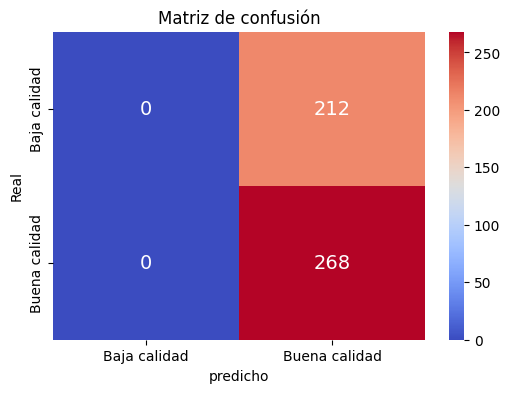

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

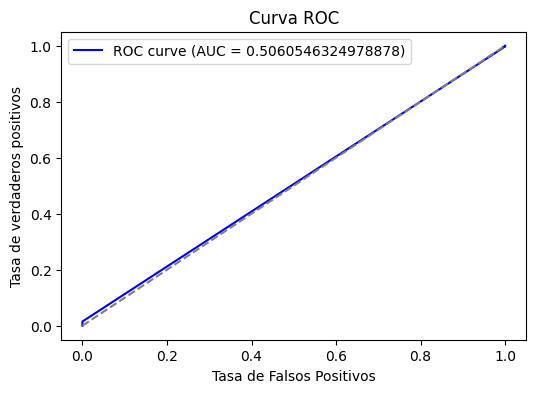

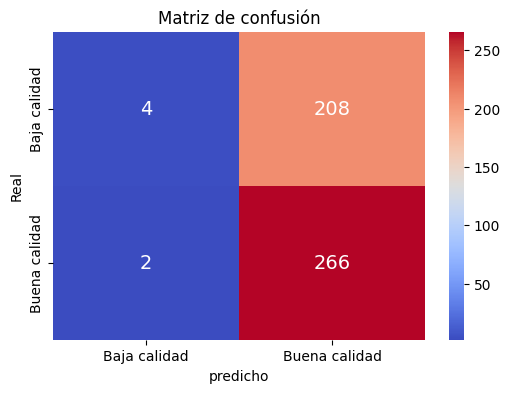

Valor de sigma: 2.0
Valores de predicción para y:
[1 1 1 0 1 1 0 1 1 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 0 0 0 0 1 1 0 0 0 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 1 1 0 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 1 1 1 1 1 0
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 0 0 0 1 1
 1 0 0 1 1 1 1 0 1 1 0 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 1 1
 1 0 0 0 0 1 0 1 1 1 0 0 0 1 0 1 0 0 1 1 1 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1

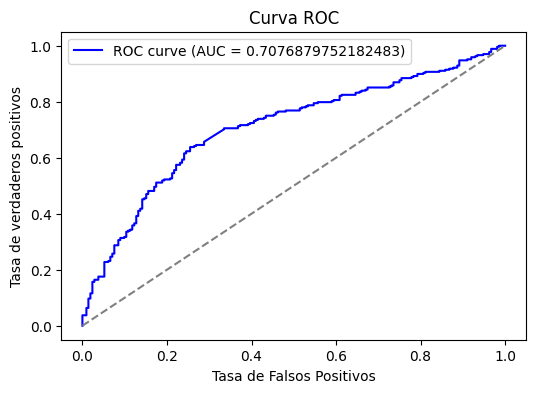

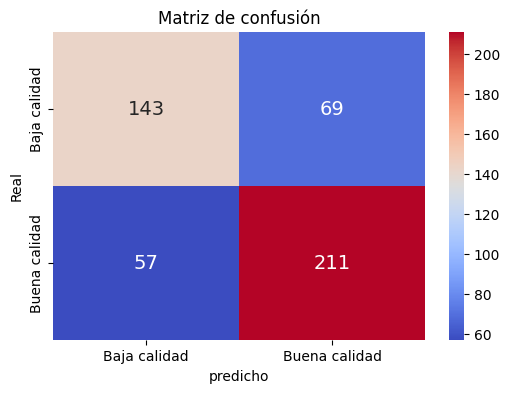

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 1
 1 1 1 0 0 0 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 0 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 1 1 1 1 0 1 1 1 1 1
 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1

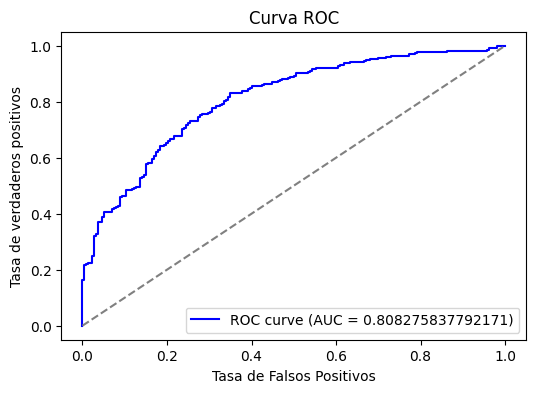

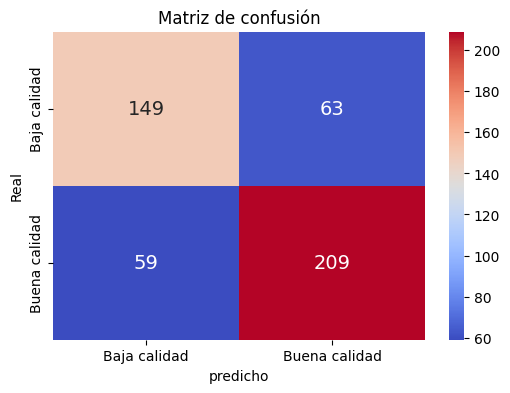

Tamaño del conjunto de prueba: 0.2
Cantidad de centros: 5
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.584375


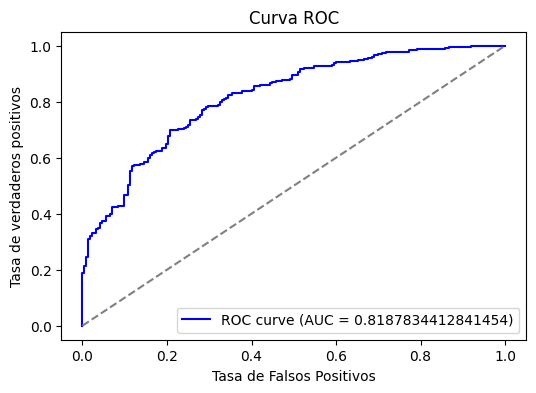

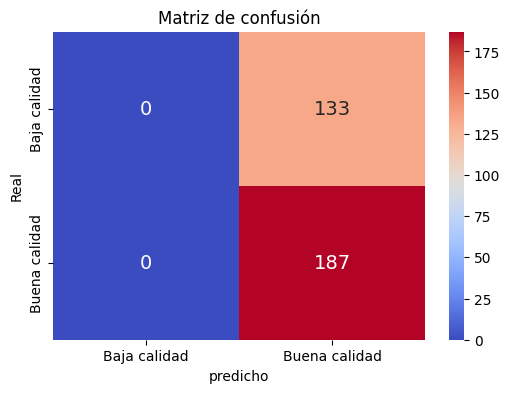

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.584375


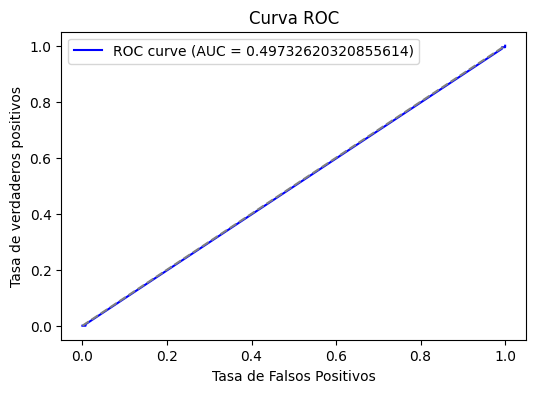

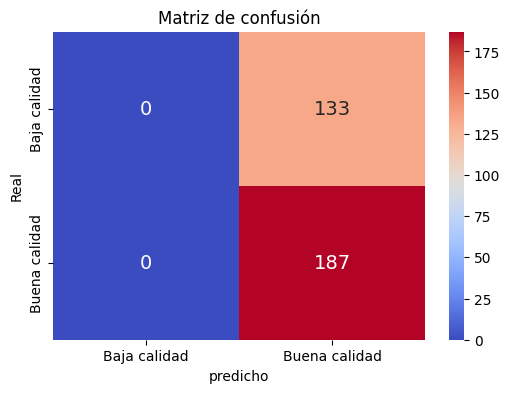

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 0 1 0 1 0 0 0 1 1 1 1 0 0 1 0 1 0 0 1 0 0 1
 0 1 0 0 1 1 1 0 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 0 1 1 1 1 0 1 0 0 0 1 1 1 1
 0 1 1 1 0 1 0 1 0 0 0 1 1 0 1 0 1 0 0 0 0 1 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1
 0 0 1 0 0 0 1 0 1 0 0 0 1 1 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0
 1 1 0 1 0 1 0 1 0 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 1 1 0 1 1 1 0 1 0 1 1 1
 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 0 1 1 0 0 1 0 0 1 1
 0 0 1 1 0 1 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0 0 1 1 0 1 0 1 1 0 1 0 1 1 0 1 0 1 0 1
 1 0 0 0 0 1 1 0 0 1 0 0 0 0 1 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.678125


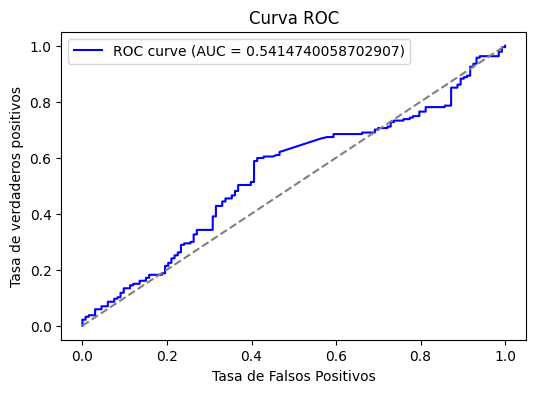

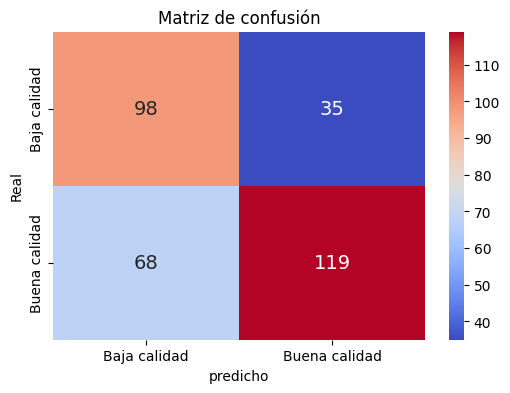

Valor de sigma: 5.0
Valores de predicción para y:
[1 0 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 0 0 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 0 1 1 1 0 1
 1 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0
 1 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 1 0
 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 0 1 1 1 0 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1
 1 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.721875


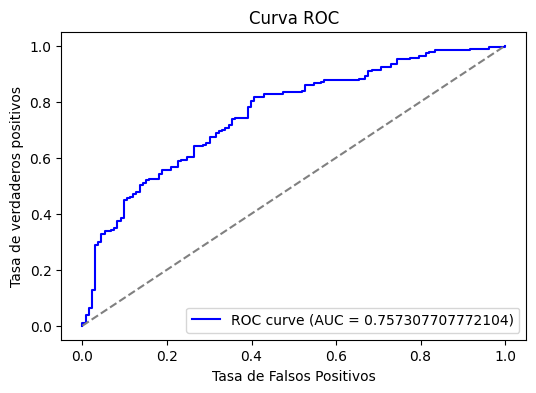

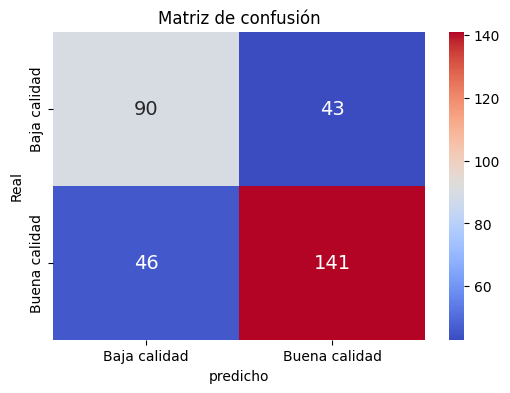

Cantidad de centros: 15
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.584375


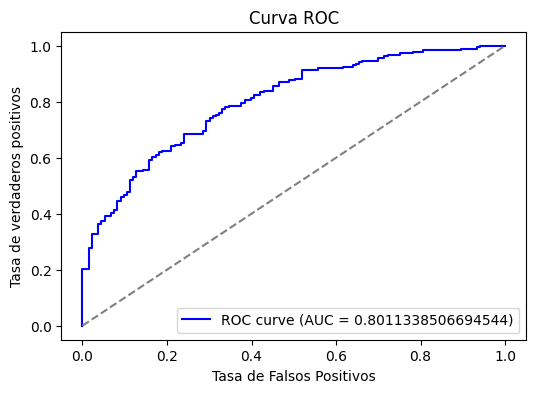

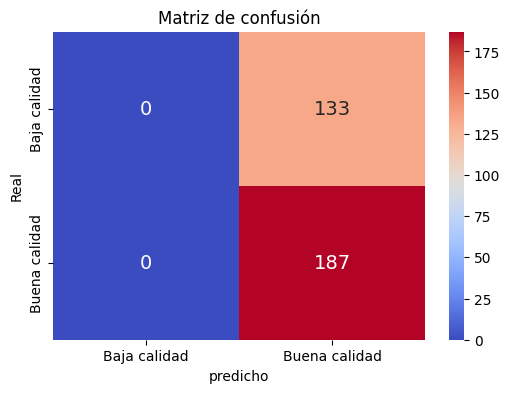

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.5875


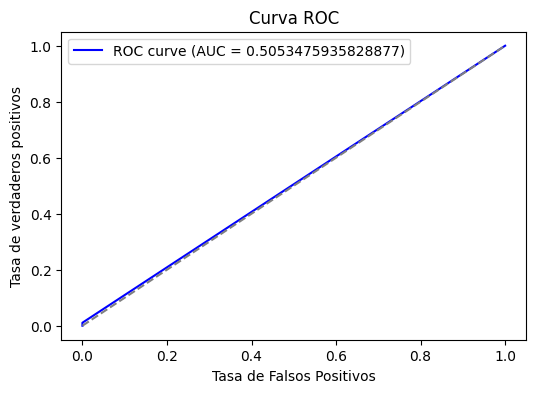

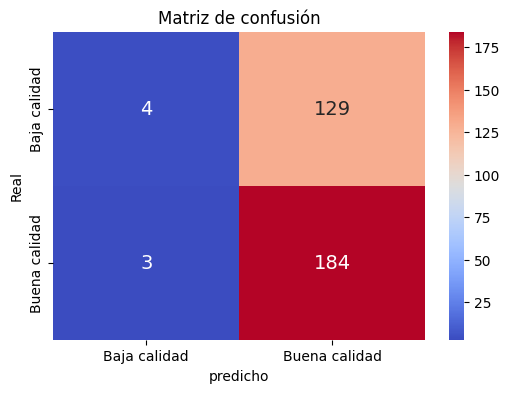

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 0 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 1 0 0 1 1 1 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0
 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 0 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0
 1 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.721875


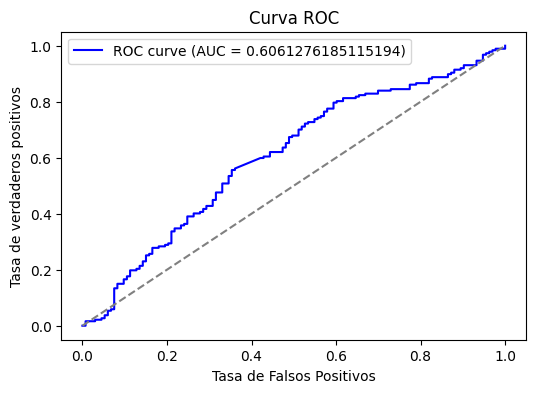

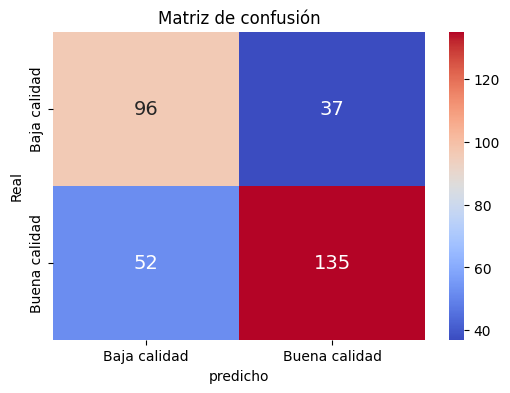

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 0 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0
 1 1 0 0 0 1 0 0 0 1 1 1 0 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.746875


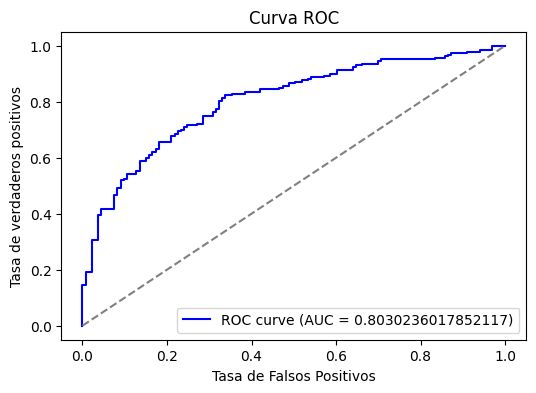

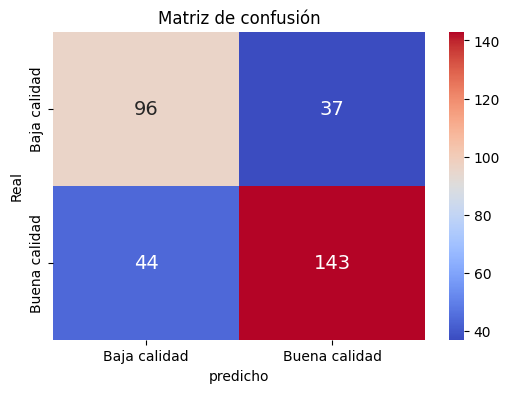

Cantidad de centros: 20
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.584375


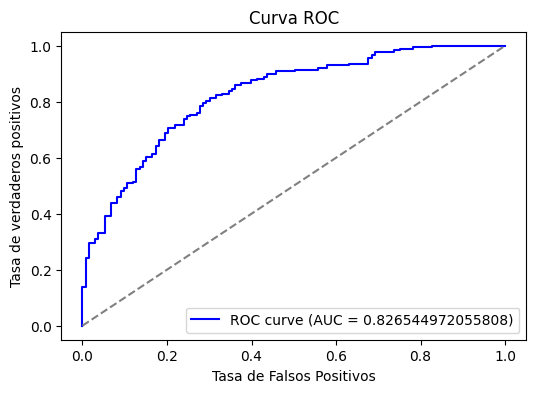

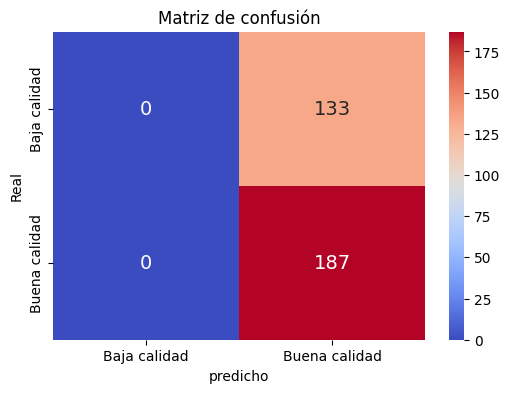

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.6


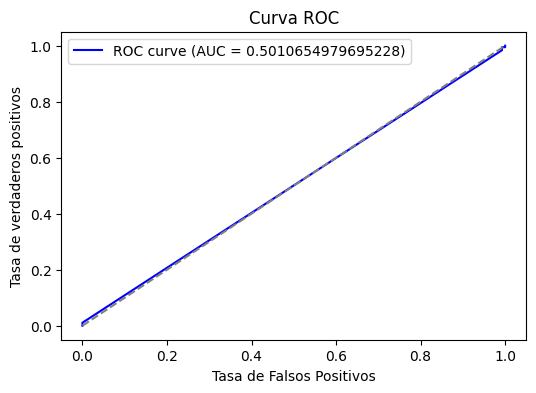

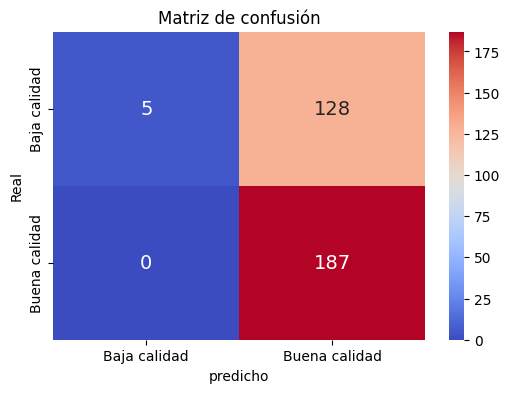

Valor de sigma: 2.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1
 0 1 0 0 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 1 1 0 0 0 0 1 0 1 0 1 1 0 1 1 1 1 1 0 1 0
 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 0 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.7625


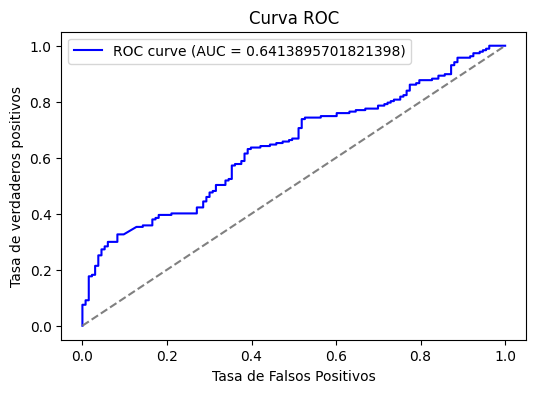

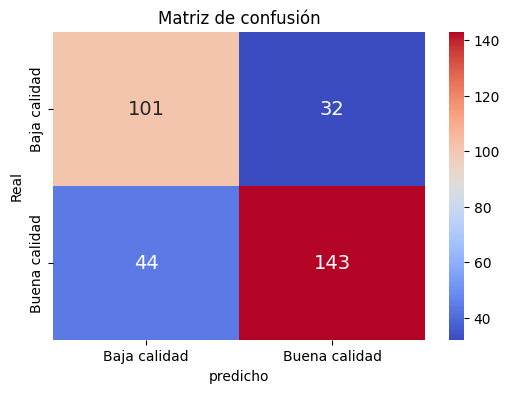

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 1 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 0
 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.759375


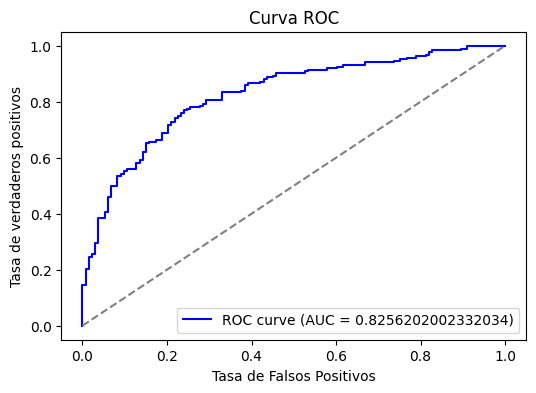

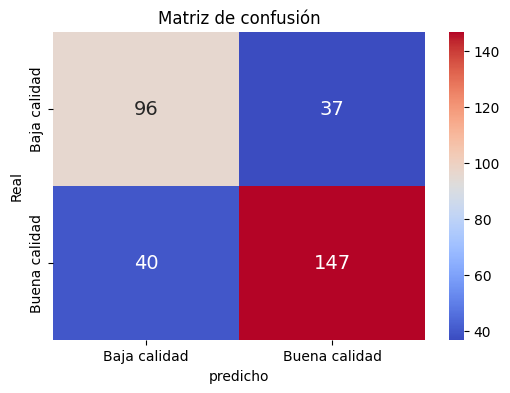

Cantidad de centros: 25
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.5875


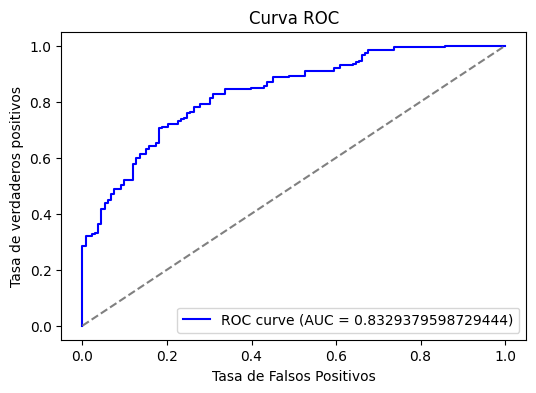

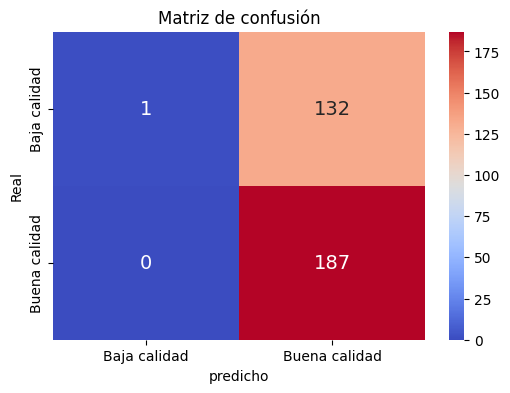

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.59375


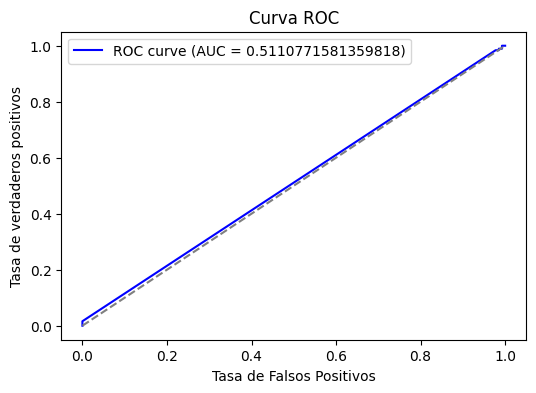

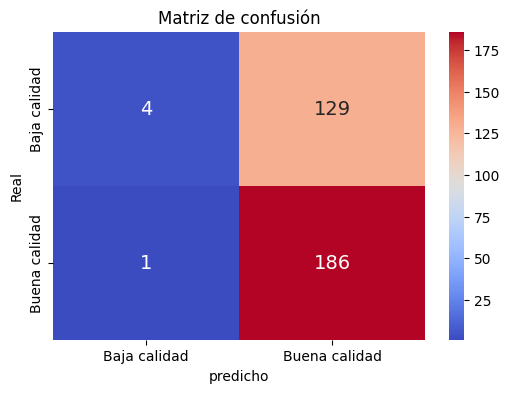

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 0 1 1 0
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 1 1 0 0 1 1 1 1 0 1 0
 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.75


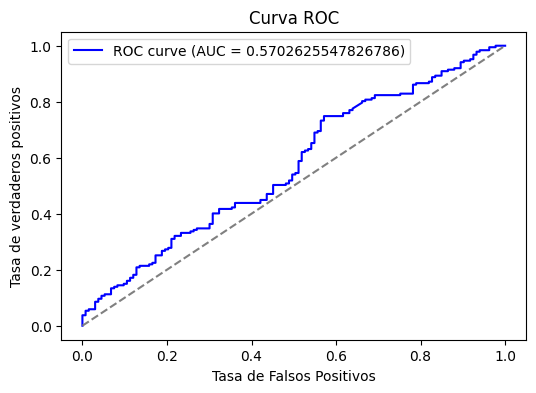

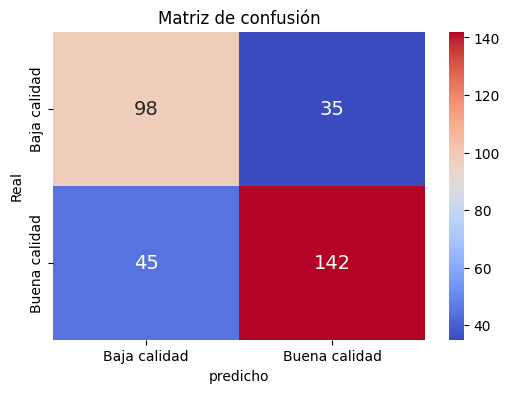

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.759375


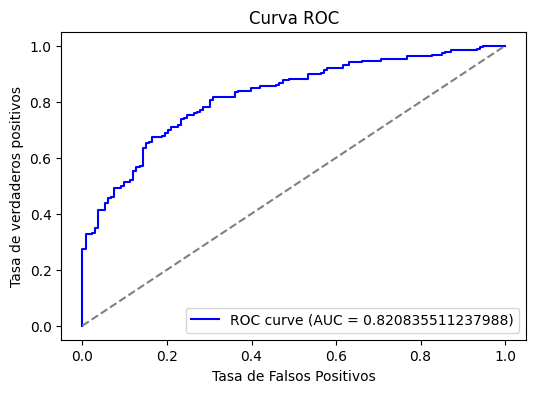

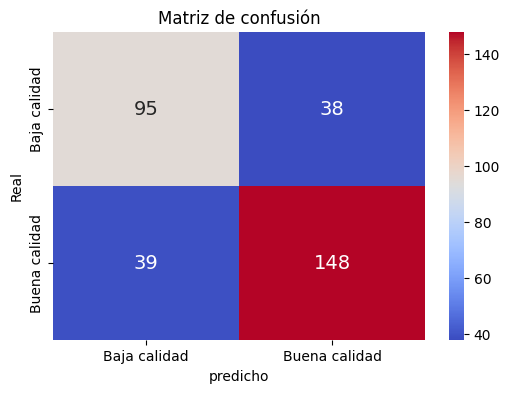

Cantidad de centros: 30
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.5875


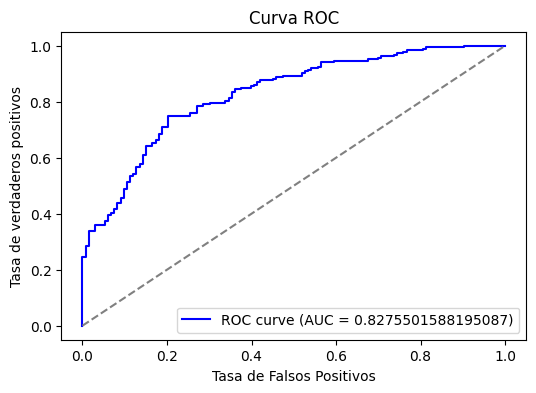

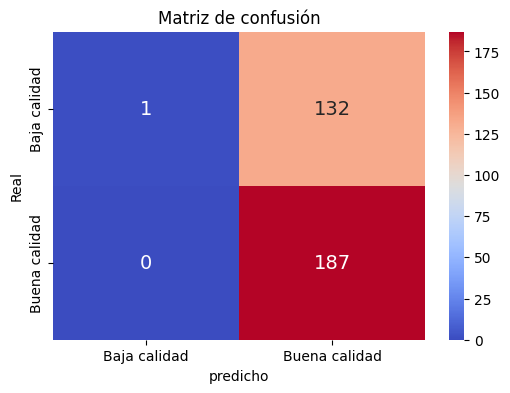

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.590625


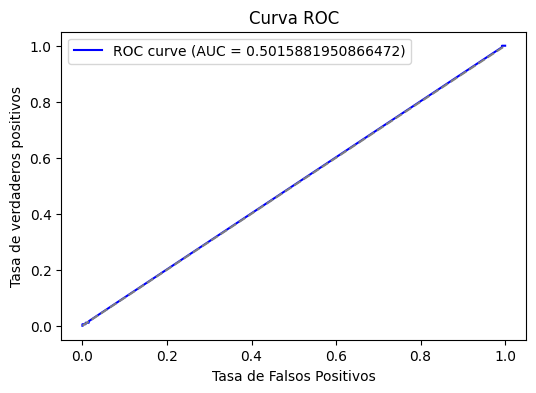

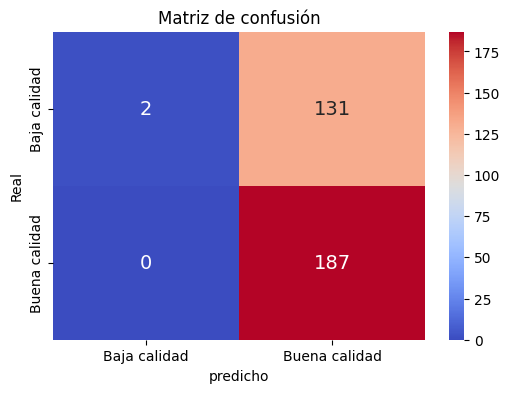

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 1 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0
 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.75625


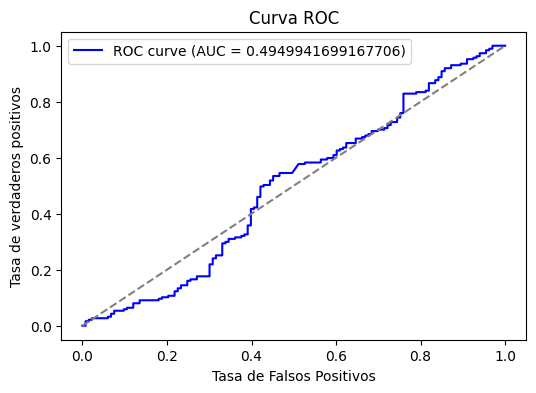

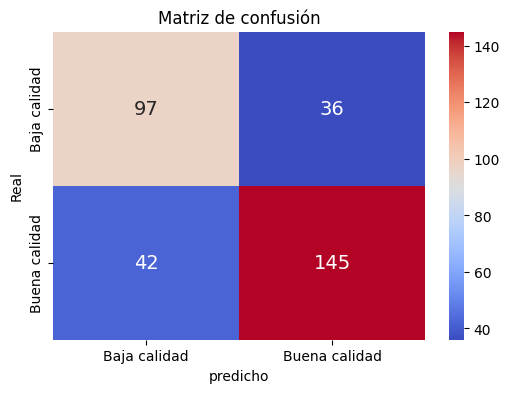

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.759375


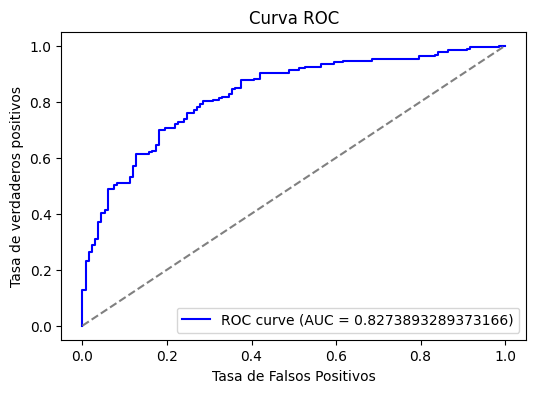

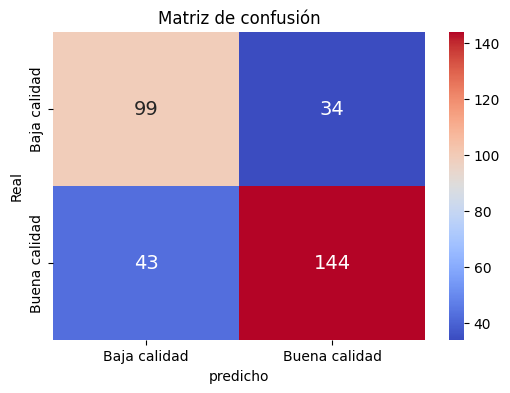

Tamaño del conjunto de prueba: 0.1
Cantidad de centros: 5
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.63125


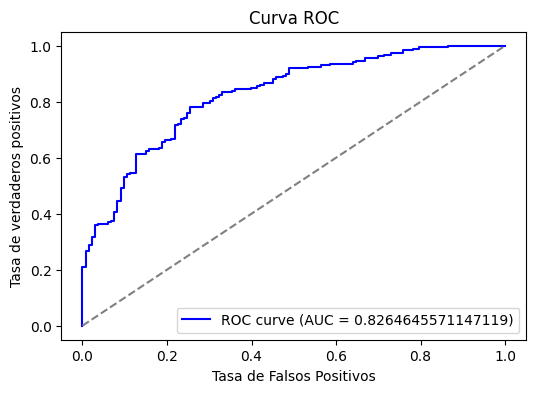

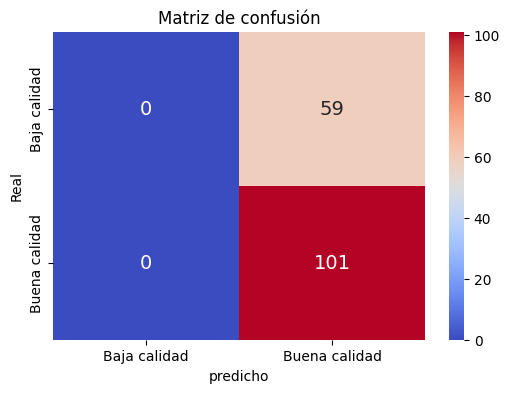

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.6375


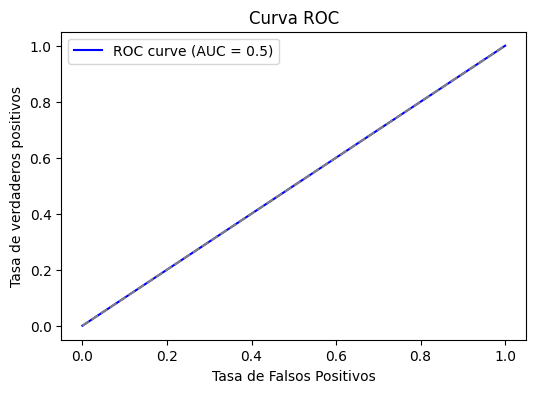

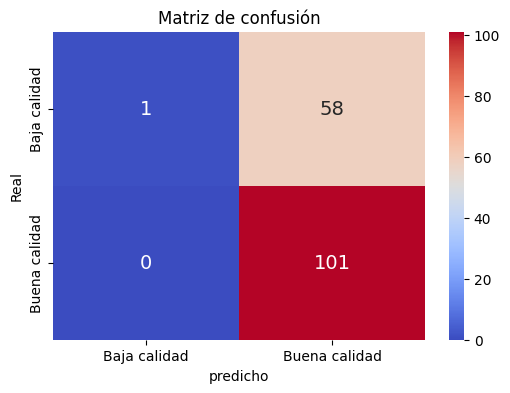

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 0 0 1 0 0 1 1 1 0 0 0 1 0 1 1 0 1 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 0 1 1 1 1 1 1
 0 1 0 0 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 1
 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 1 1 0 1 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0
 1 0 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.65625


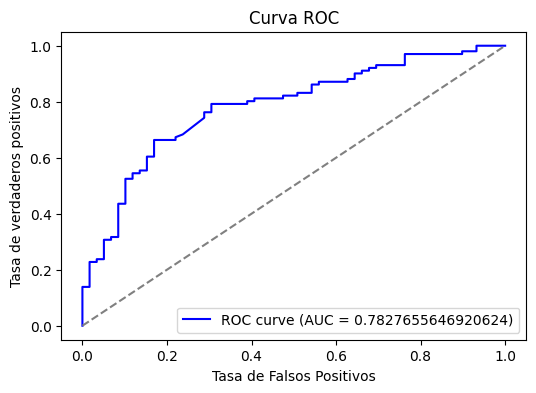

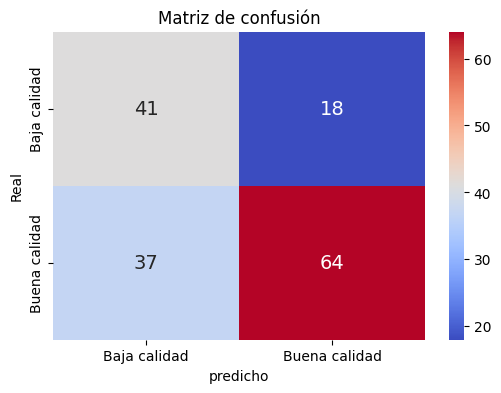

Valor de sigma: 5.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 1 1 1 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 1 1 0 1 0 0 0 0 0 1
 0 1 1 1 1 1 1 0 0 0 1 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0
 0 1 1 0 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 1 1 1 1
 1 1 1 1 0 1 1 0 1 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 0 0 0 0 0 1 0 1 0 0 1 0
 1 1 0 0 0 1 0 1 0 1 1 0]
Precisión del modelo: 0.6875


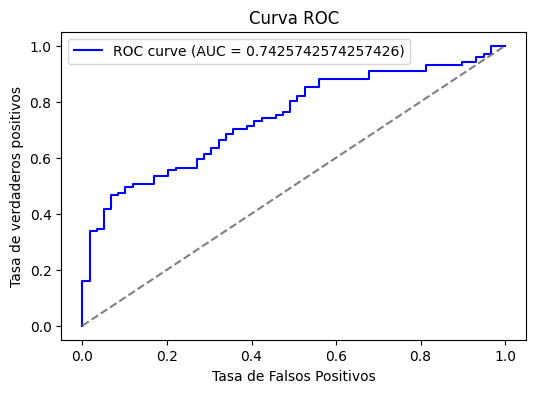

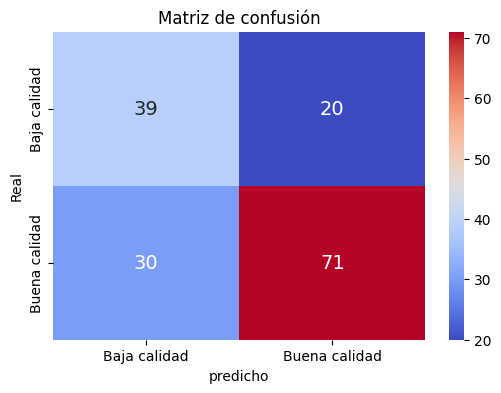

Cantidad de centros: 15
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.63125


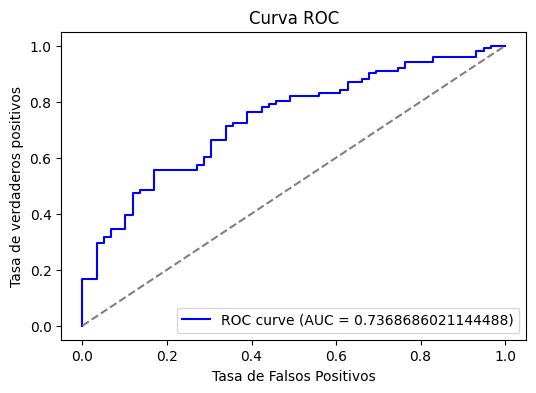

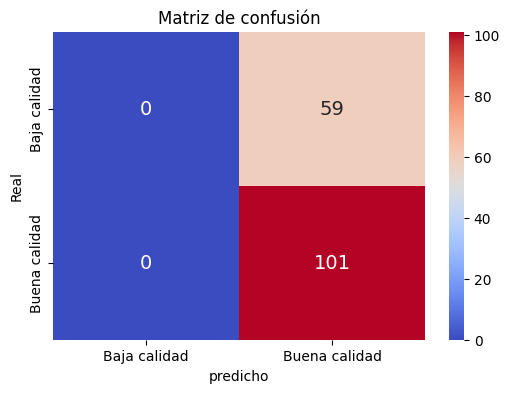

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.6125


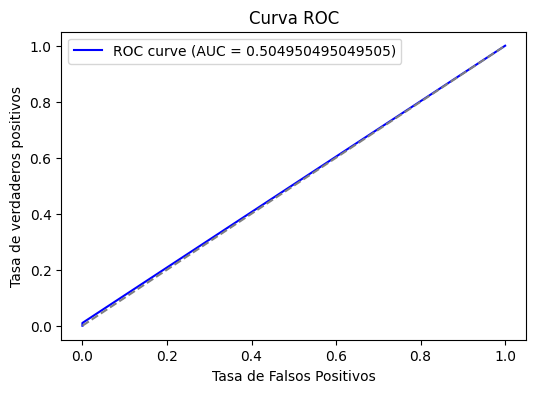

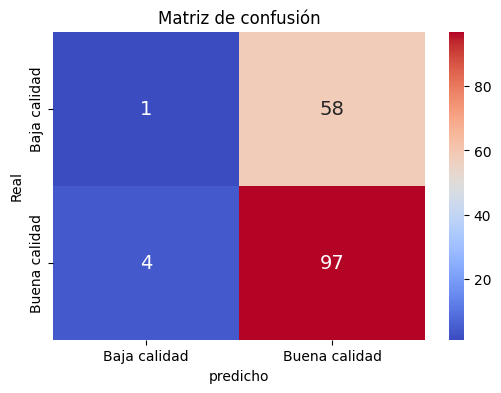

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0
 0 1 0 1 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.725


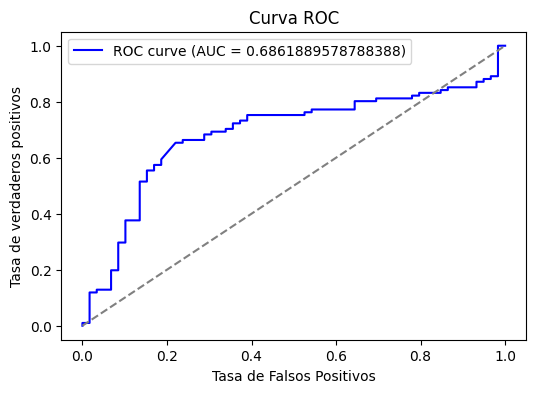

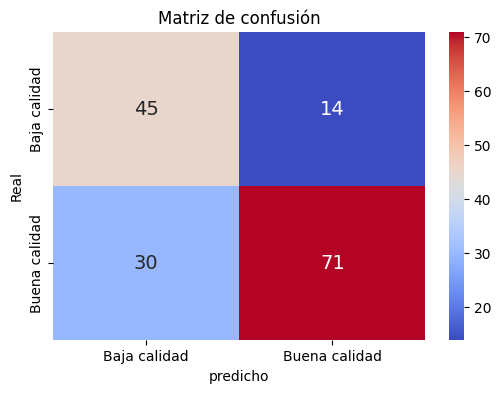

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.73125


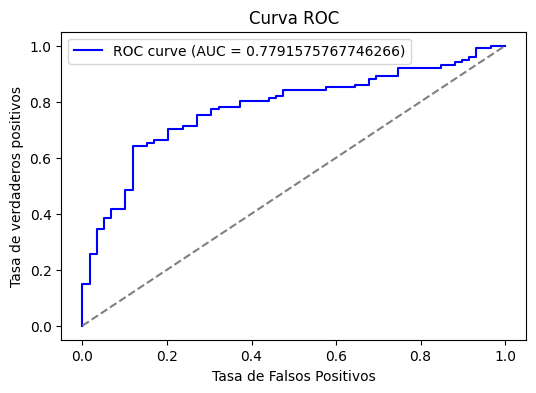

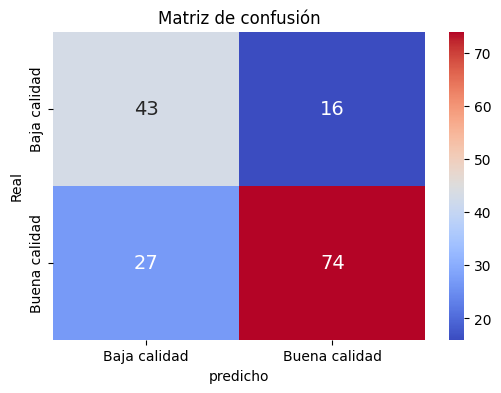

Cantidad de centros: 20
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.63125


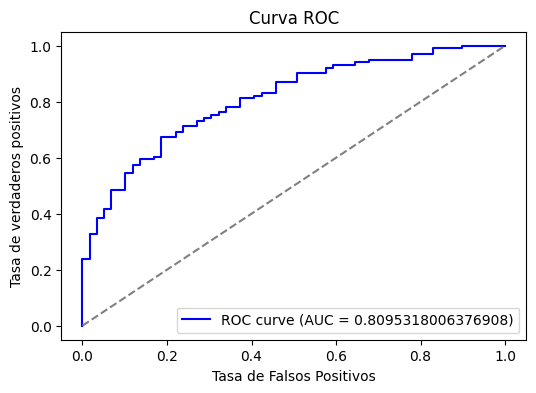

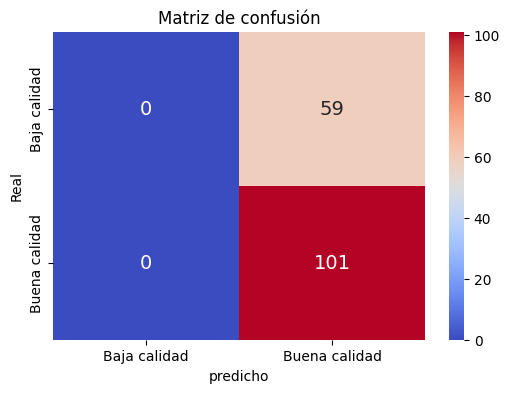

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.6375


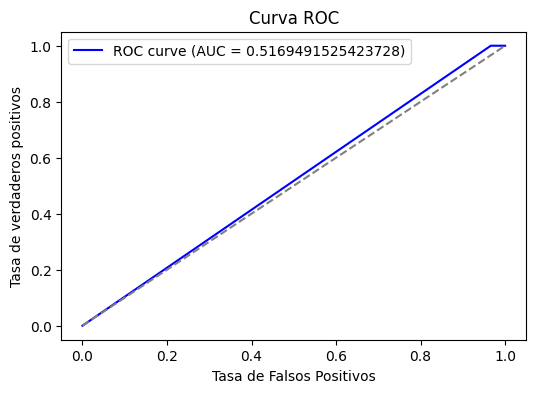

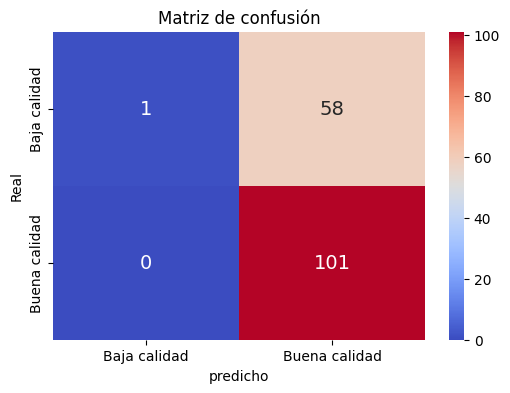

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 0 0 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 1 0 1 1 0 1 0 1 0 1 0 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.73125


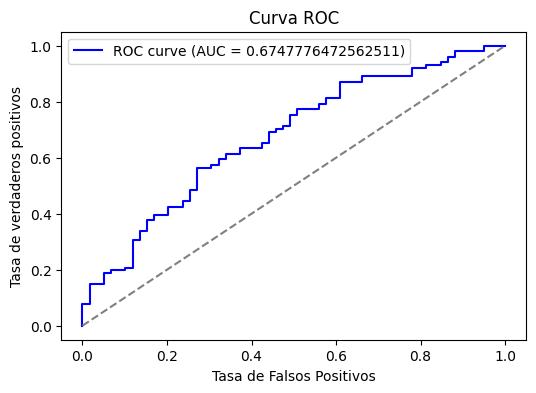

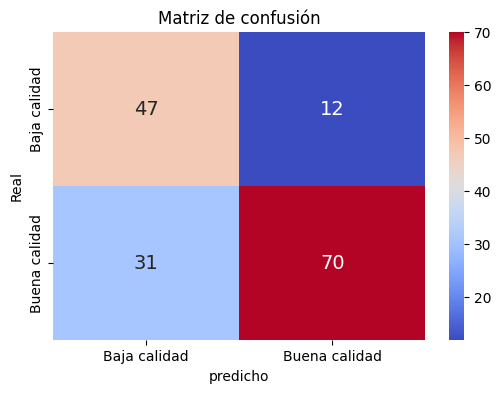

Valor de sigma: 5.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.73125


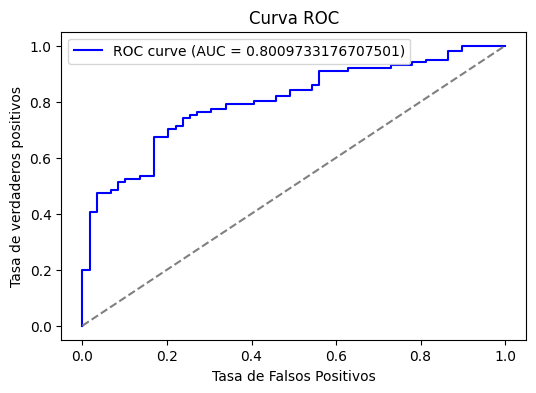

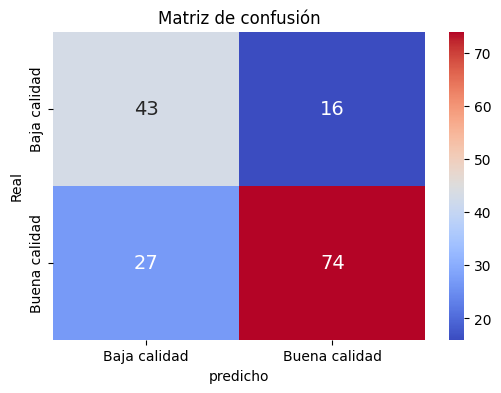

Cantidad de centros: 25
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.63125


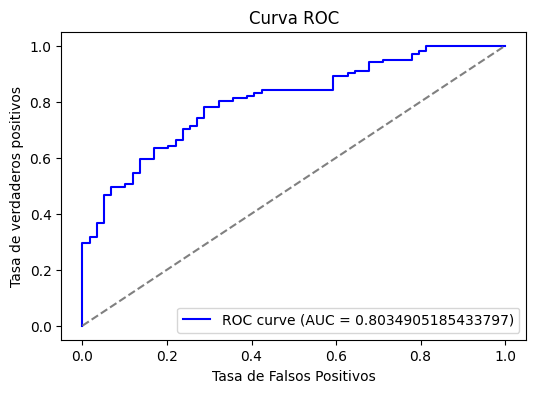

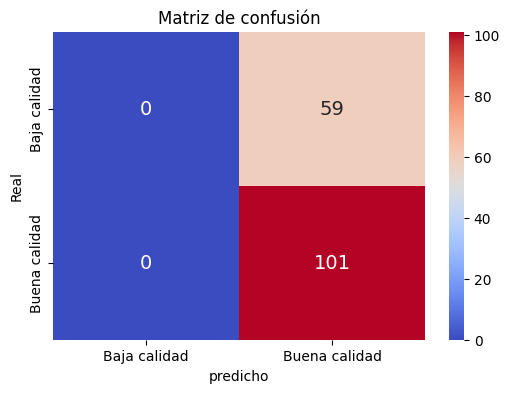

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.6375


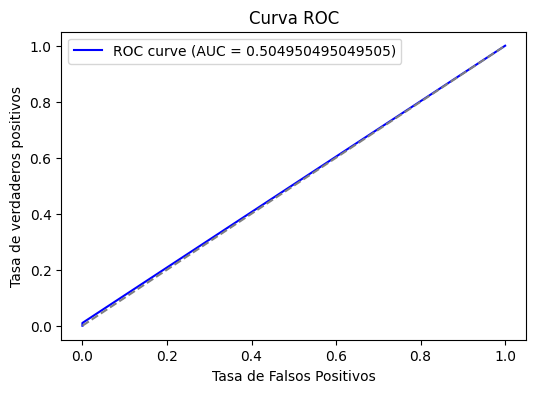

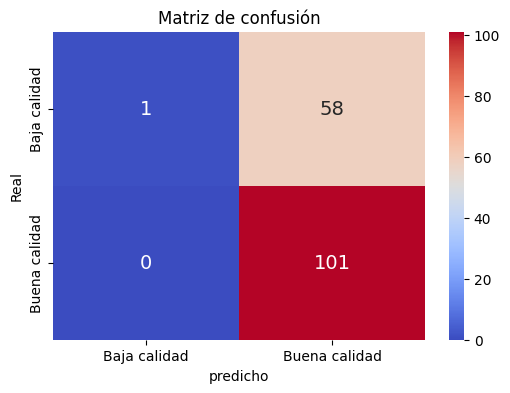

Valor de sigma: 2.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 0 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.71875


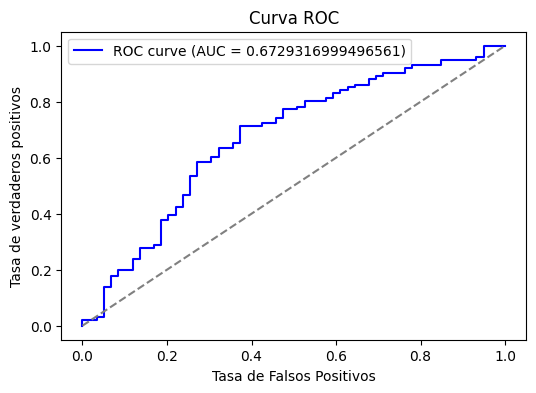

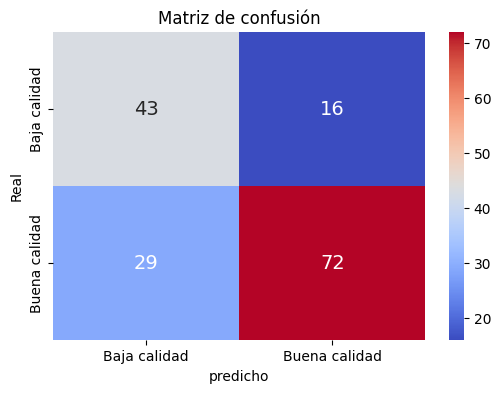

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 0 0 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 0 1 1 1 1 1 1
 0 1 1 1 0 1 0 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0
 1 1 0 0 0 1 0 1 0 1 1 1]
Precisión del modelo: 0.6875


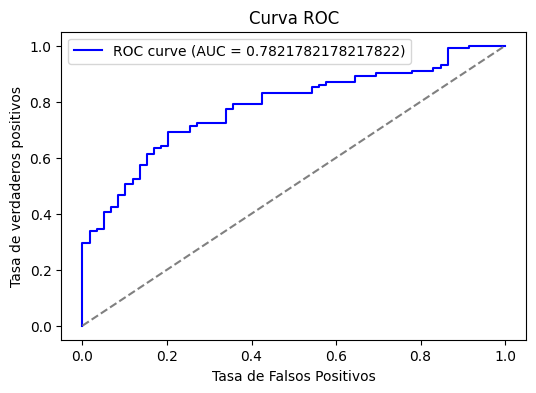

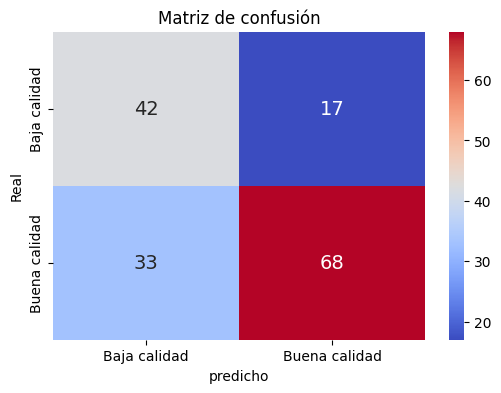

Cantidad de centros: 30
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.6375


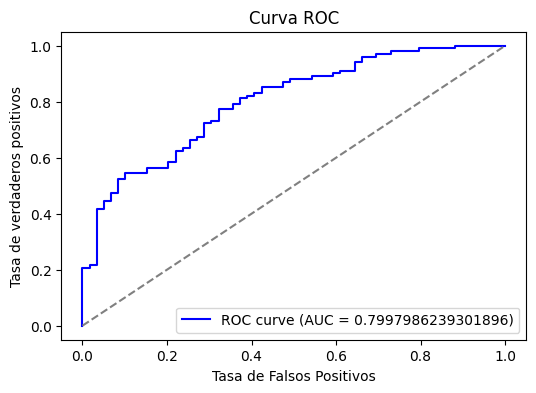

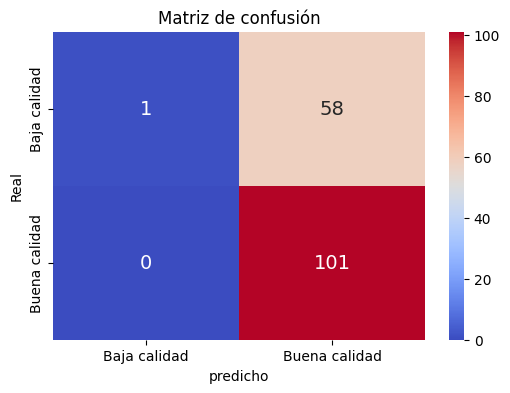

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.64375


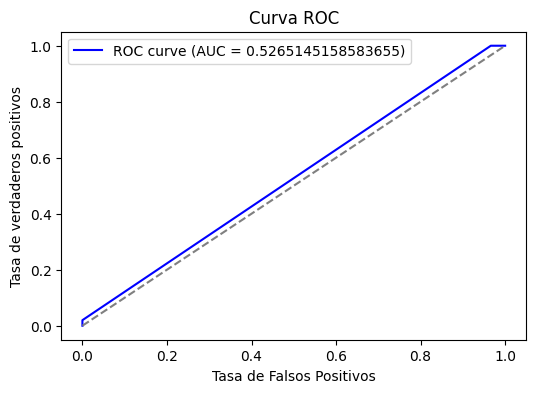

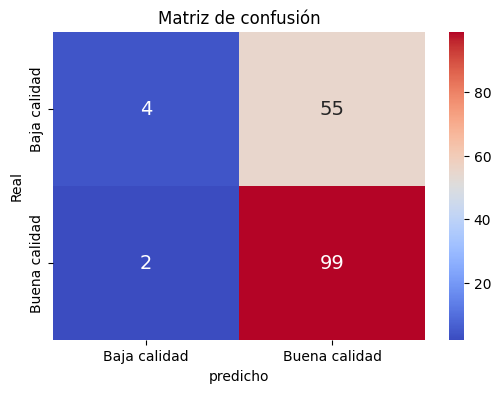

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.75625


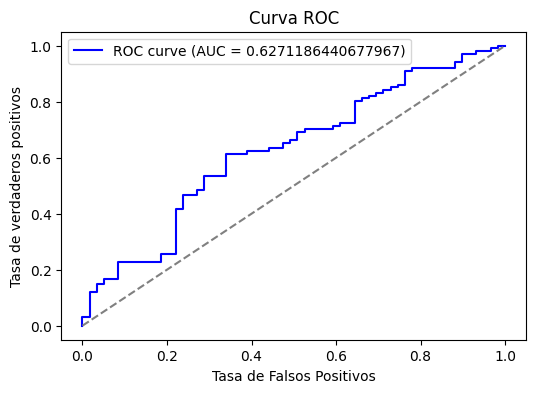

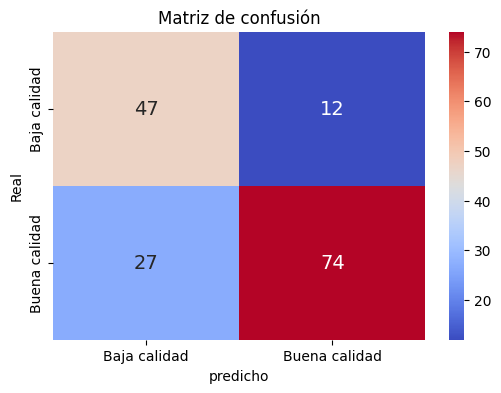

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.71875


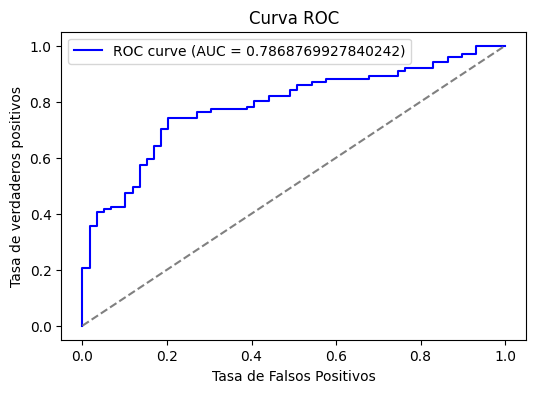

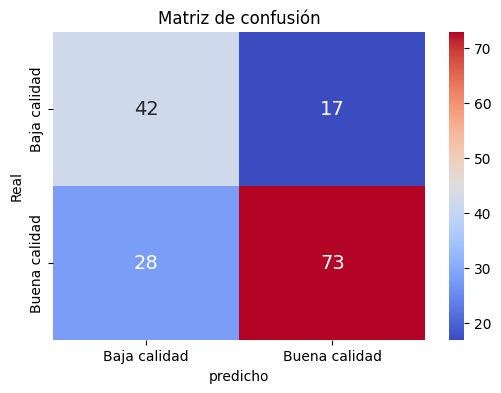

Tamaño del conjunto de prueba: 0.3
Cantidad de centros: 5
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 

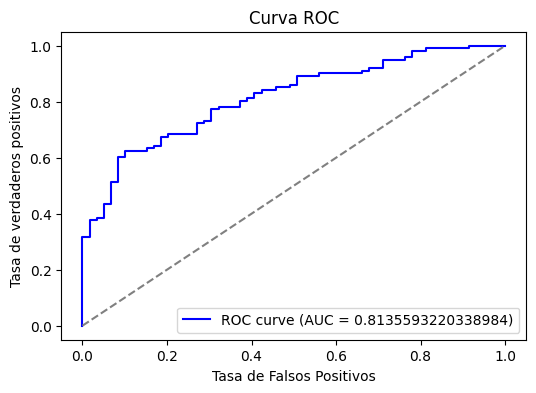

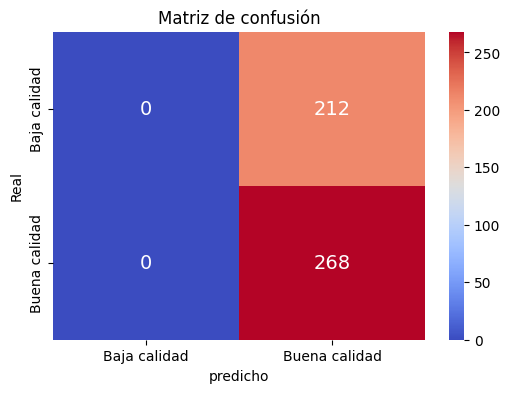

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

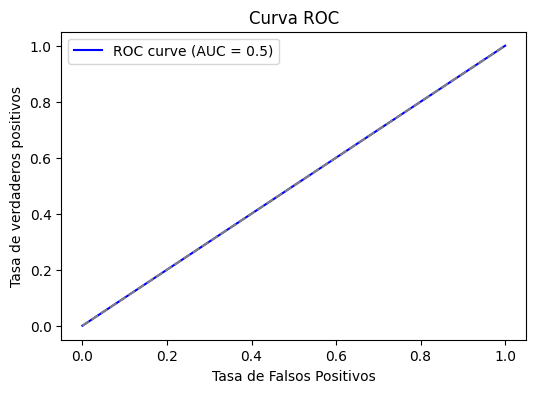

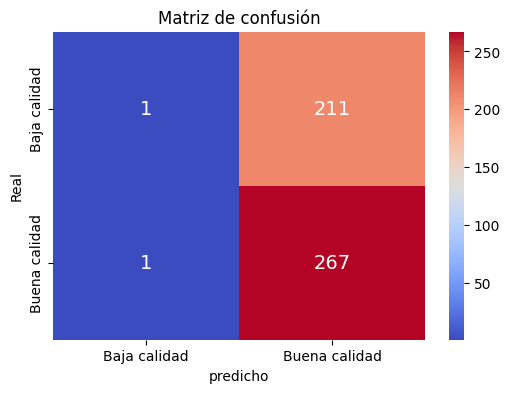

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 1 0 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1
 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 0 1 0 1 1 0 0 0 1 0 1 1 1 1 1 1
 0 1 1 1 0 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 0 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 1 0 1 1 1 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0
 1 0 0 1 0 1 0 1 0 0 1 1 0 1 1 1 0 0 0 0 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0
 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 0 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1
 1 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0 0 1 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 0 1
 1 0 0 1 0 1 1 1 0 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 0 0 1 1 1 0 1 1
 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 1 1 1 0 1 0 1 0 1 1 1 1 1 0 1 1 0 0 0 1 1
 1 0 0 1 1 1 1 0 1 1 0 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 0 0 0 1 0 1 0 0 1 1 1 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1

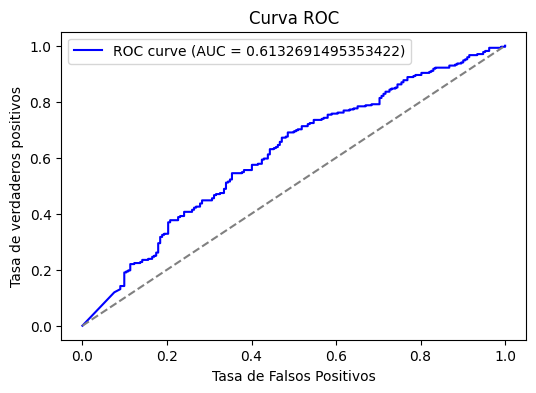

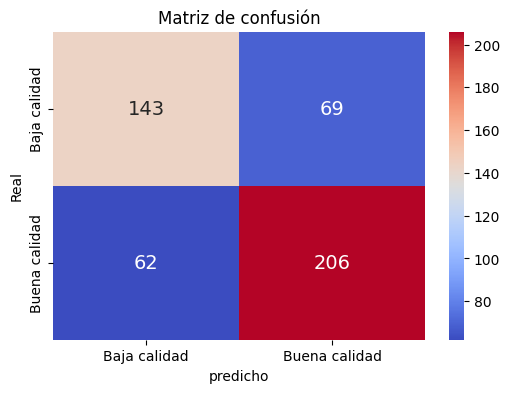

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 0 1 0 0 1 1 1 0 0 0 1 0 1 0 0 0 1 1 1 1 1 0 1 0 1 0 0 1 0 0 1
 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1
 0 1 0 1 0 1 0 1 0 0 0 1 1 0 1 1 1 0 0 0 1 1 1 0 1 1 0 0 1 0 0 1 0 1 1 1 1
 1 0 1 0 0 0 1 0 1 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 1 1 1 0 0 1 0
 1 1 0 1 1 1 0 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 1 1
 1 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 0 1 1 0 0 1 1 0 1 1
 0 0 1 1 0 1 1 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 0 0 1 1 0 1 0 1 1 0 1 0 1 1 0 1 1 1 0 1
 1 0 1 1 0 1 1 1 0 1 0 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 1
 1 1 1 0 0 0 1 1 1 1 0 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 0 0 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 1 1 0 0 1 0 0 1 1 0 0 0 1 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 0 1 1 1 0 1 1 0 0 0 0 1 0 1 0 0 1 1 1 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 1
 0 0 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1

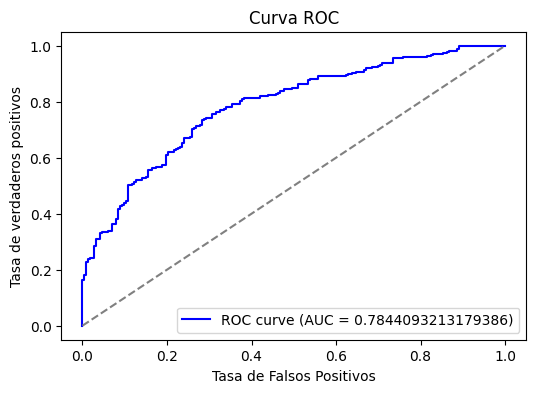

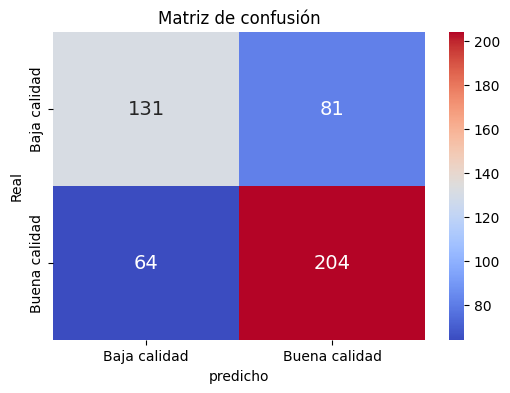

Cantidad de centros: 15
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1

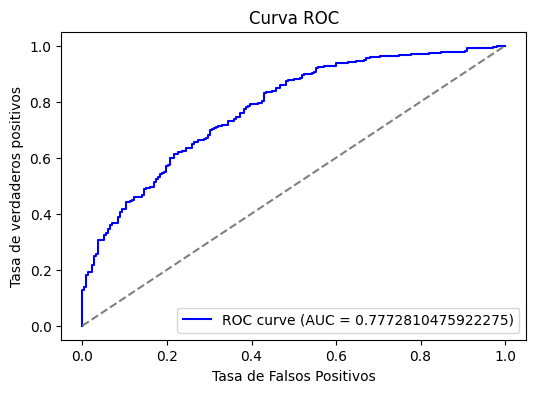

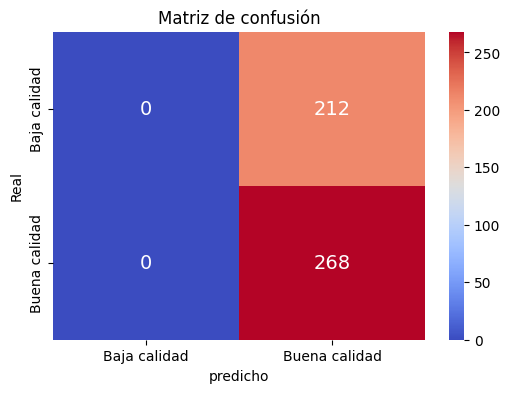

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

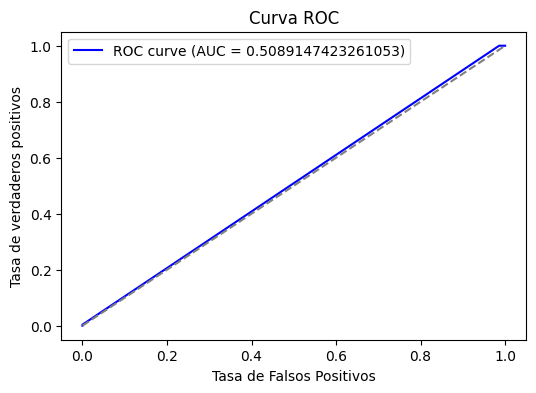

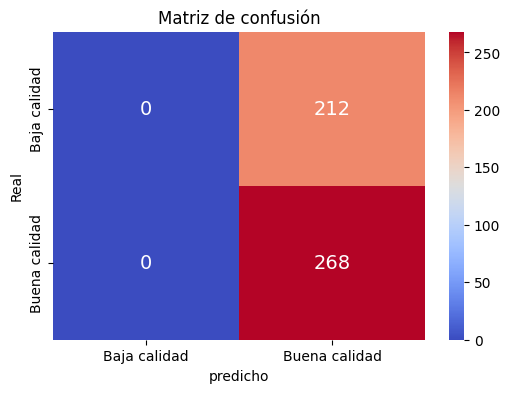

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 1 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 0 1 1 1 1 0
 1 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 0 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 1
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 0 0 0 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 1 1 0 0 0 1 1 0 1 1 1 1 0 1 1 1 1 1
 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1

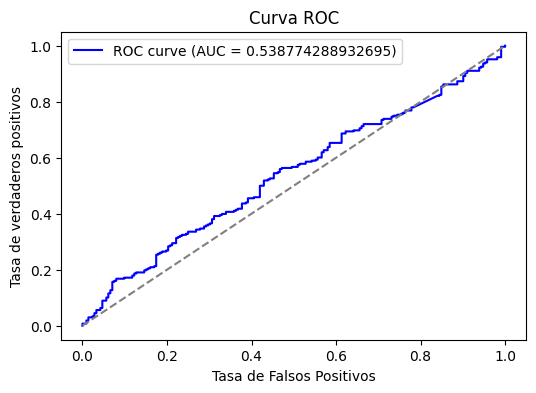

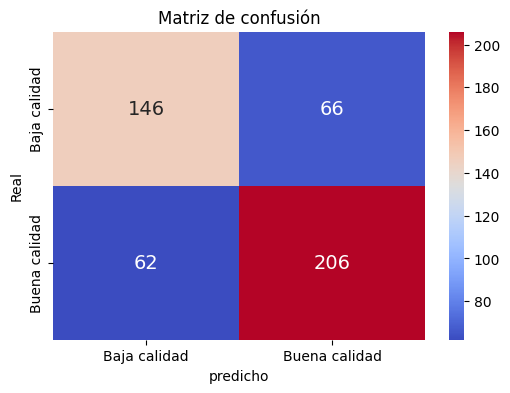

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 0 0 0 0 1 0 0 1 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 1 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 0 0 0 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 1 1 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1

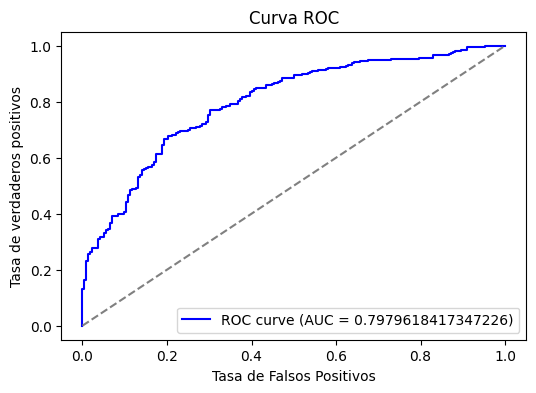

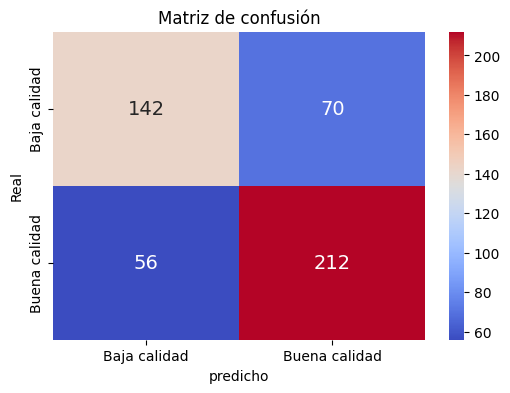

Cantidad de centros: 20
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1

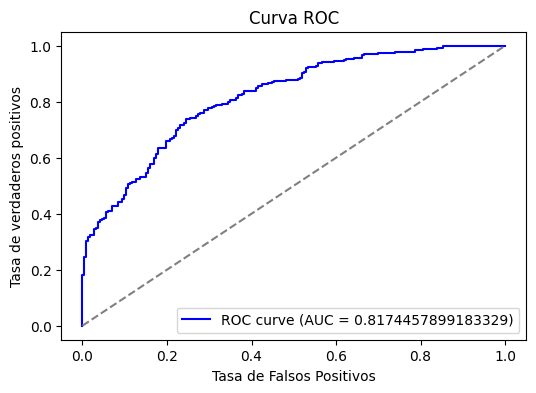

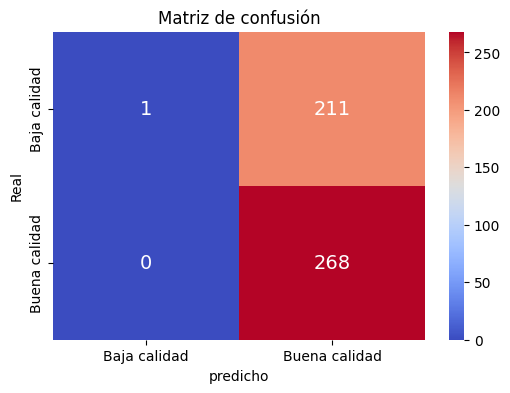

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

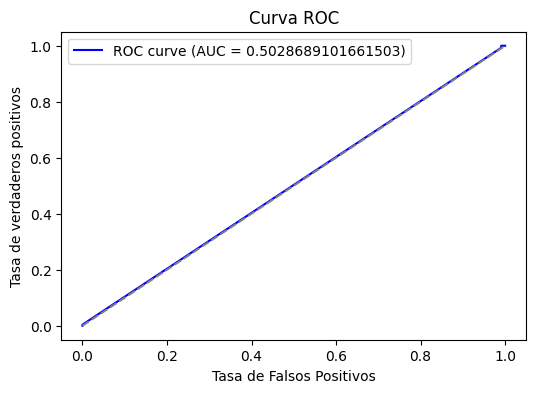

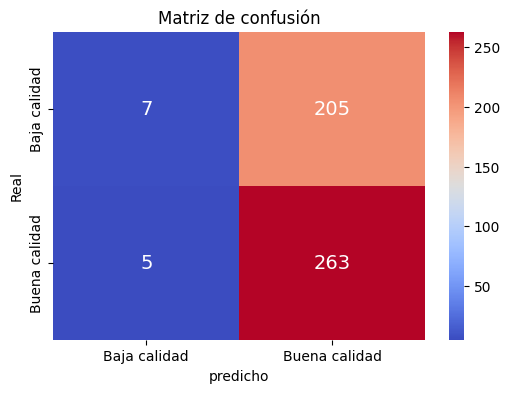

Valor de sigma: 2.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 1 0 1 0 0 1 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 0 0
 0 0 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1

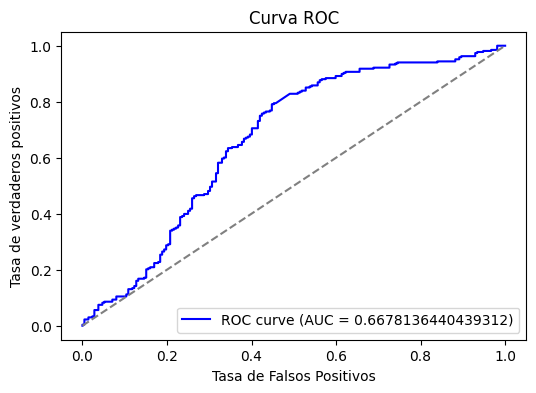

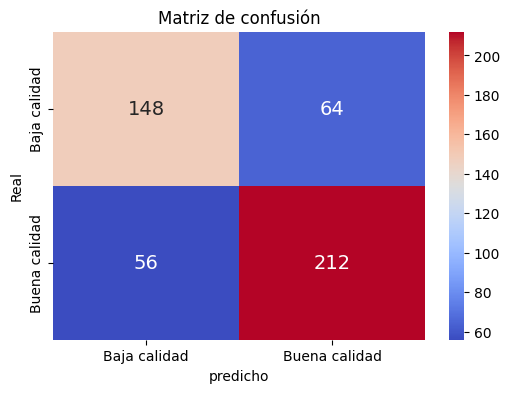

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0
 1 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 1 1 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 1 0 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 1
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 0 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 1
 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1

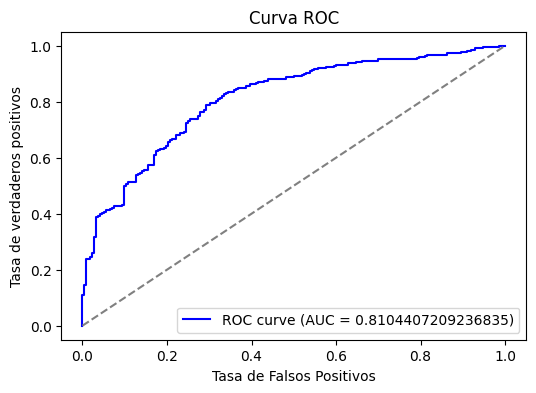

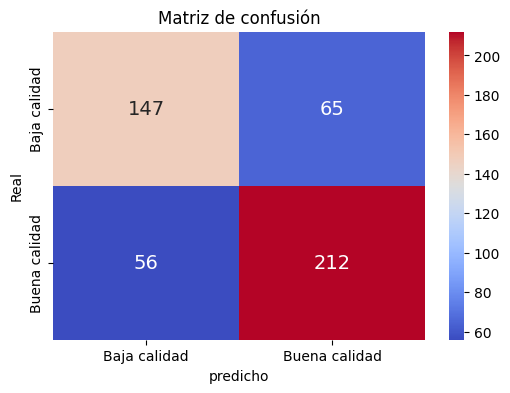

Cantidad de centros: 25
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1

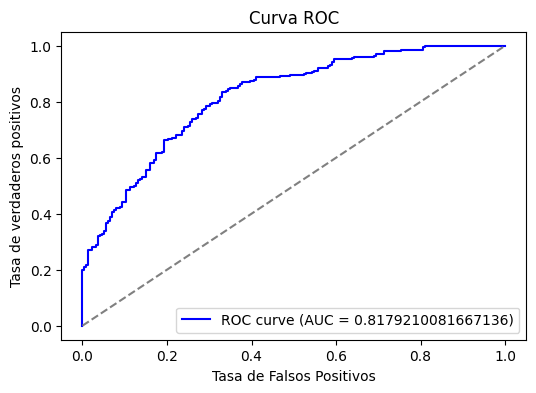

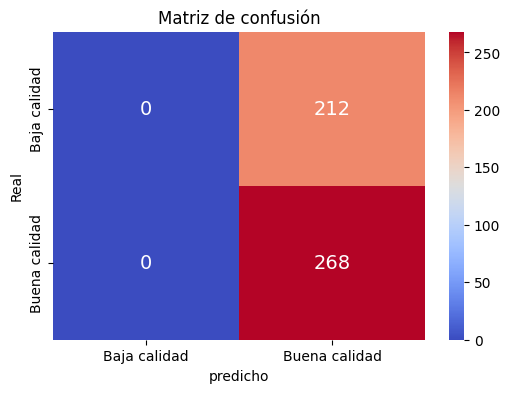

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1

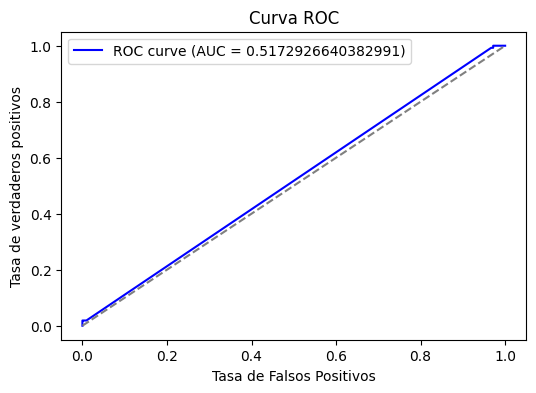

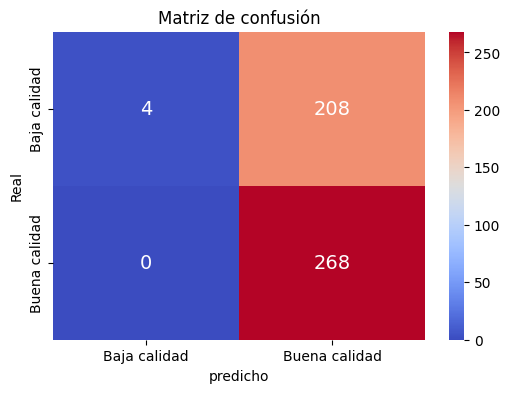

Valor de sigma: 2.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 1 1 0 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 1 0
 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 0 1 1 1 1 1 0
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 0 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1

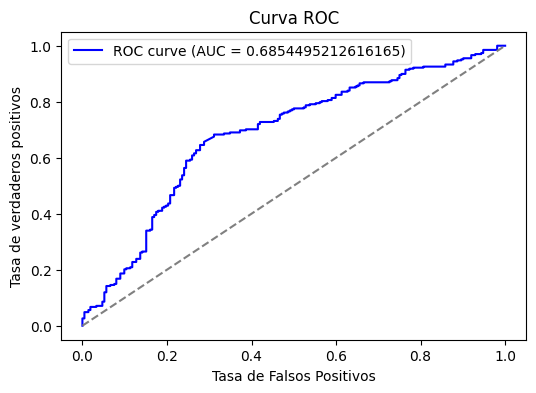

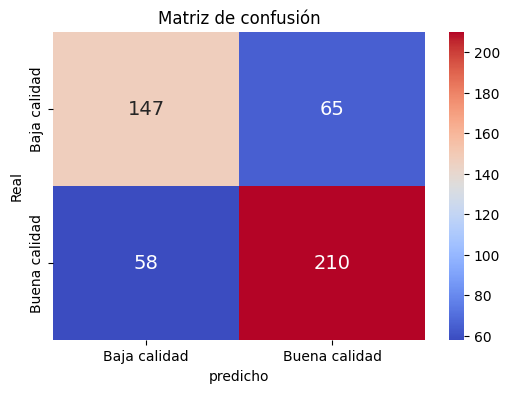

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 1 0 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 1
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 0 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1

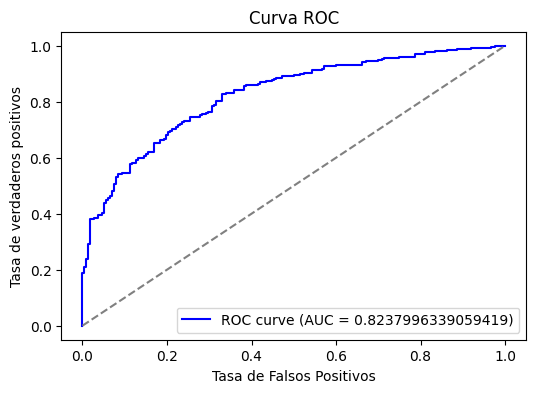

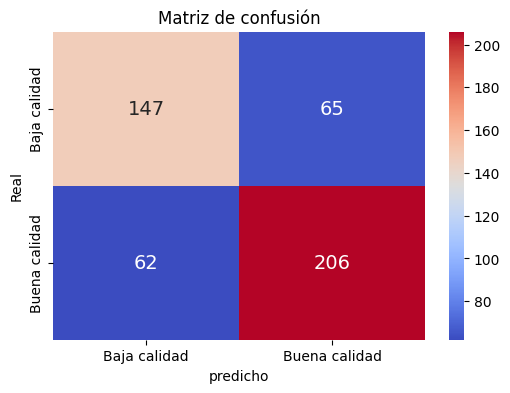

Cantidad de centros: 30
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1

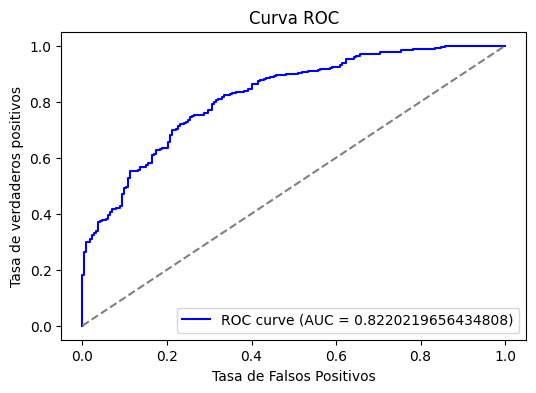

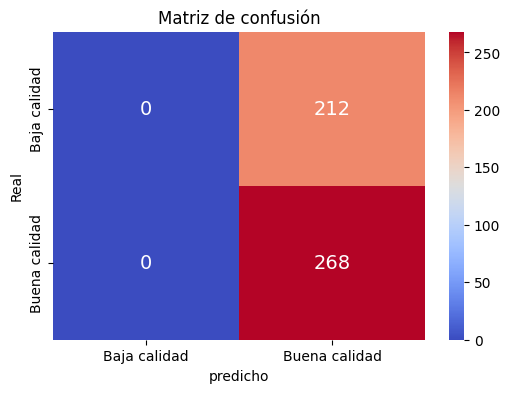

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

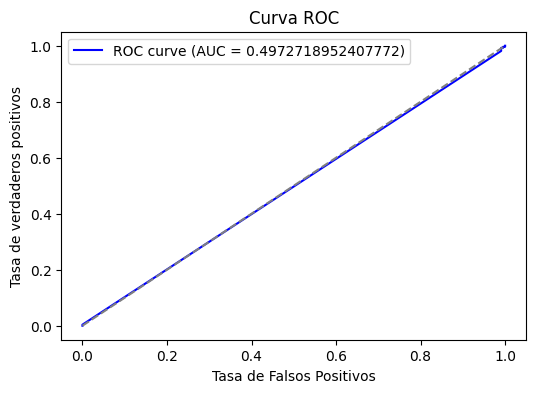

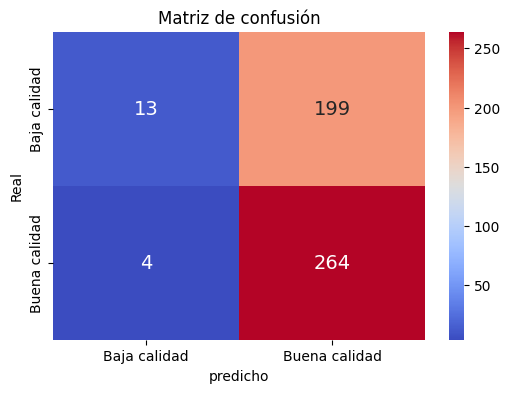

Valor de sigma: 2.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 1 0 1 0 1 0 1 0 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 1 0
 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 0 0 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1

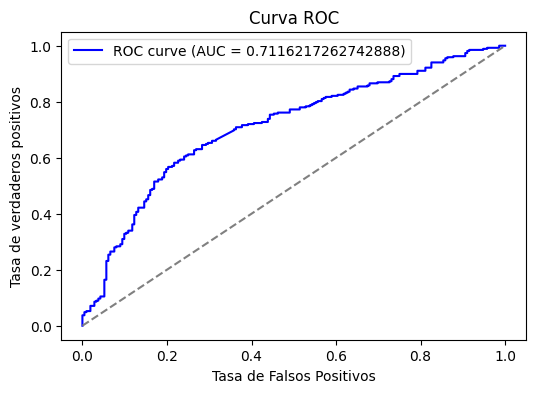

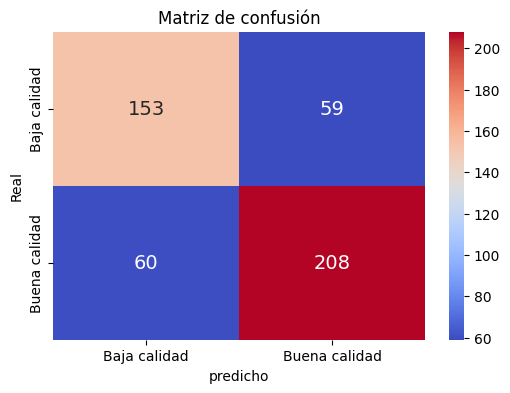

Valor de sigma: 5.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0
 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1
 1 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1
 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1
 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1

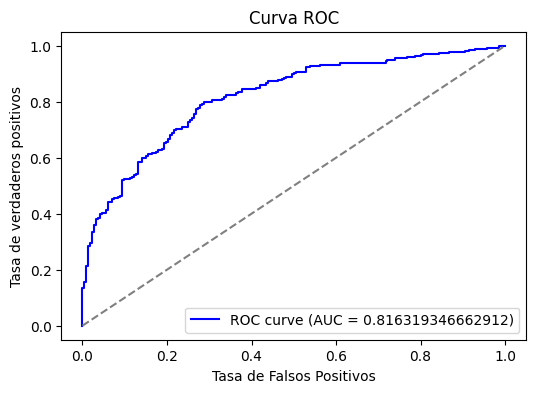

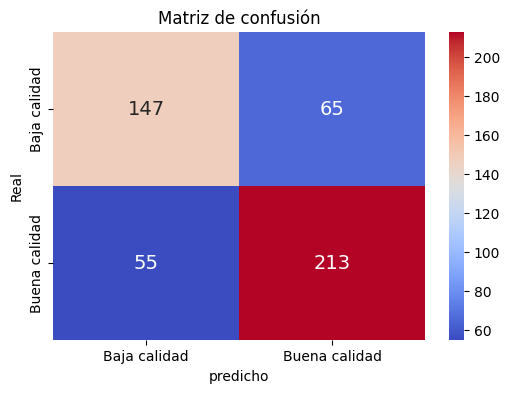

Tamaño del conjunto de prueba: 0.2
Cantidad de centros: 5
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.5875


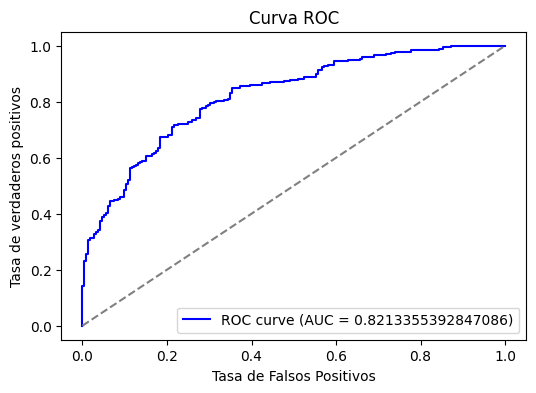

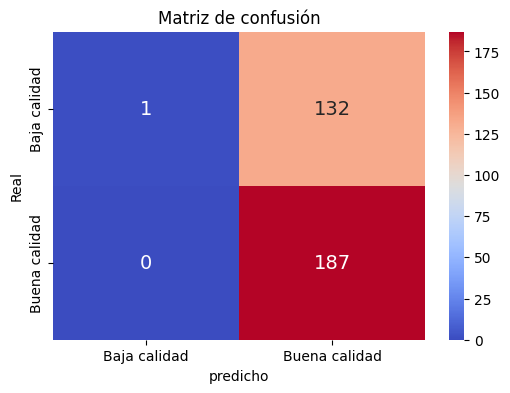

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.5875


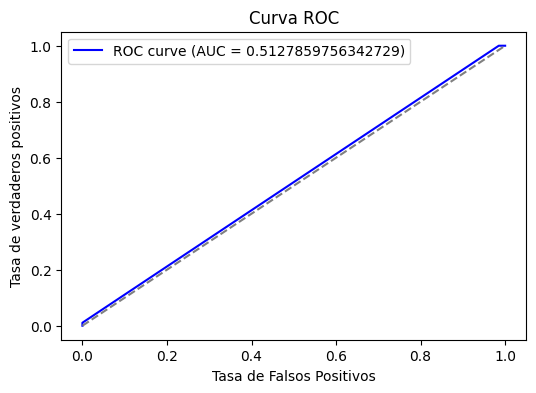

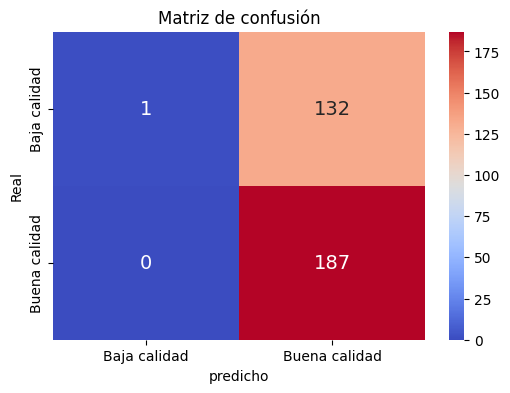

Valor de sigma: 2.0
Valores de predicción para y:
[1 0 1 0 1 1 1 1 0 1 1 1 1 0 0 0 1 0 1 1 0 0 1 1 1 1 1 0 1 0 1 0 1 0 0 0 1
 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1
 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 1
 1 1 1 0 0 0 1 1 0 0 0 0 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 1 1 0 1 0 1 1 1 0 0 1 1 1 0 1 1 1 1 0 0 1 1 1 0 1 0 1 1 1 0 1 0 1
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1
 0 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 0 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1
 1 0 0 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.7125


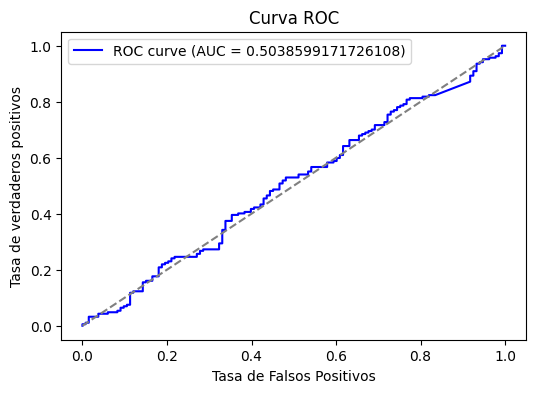

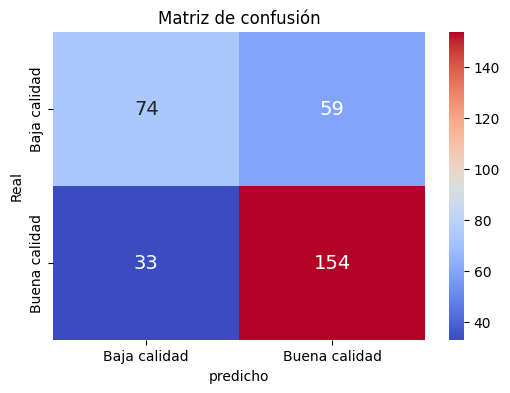

Valor de sigma: 5.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 0 1
 0 1 0 0 1 1 1 0 0 0 1 1 1 1 0 1 1 0 1 1 0 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 1 0 0 1 0 1 1 0 1
 1 1 1 0 1 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 0 0 1 0 0 1 1 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 1 0 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 0 0
 1 0 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.74375


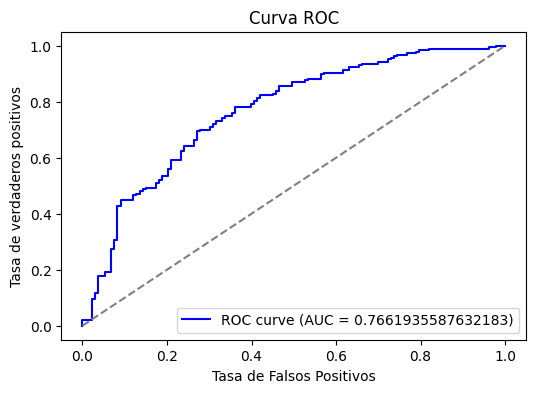

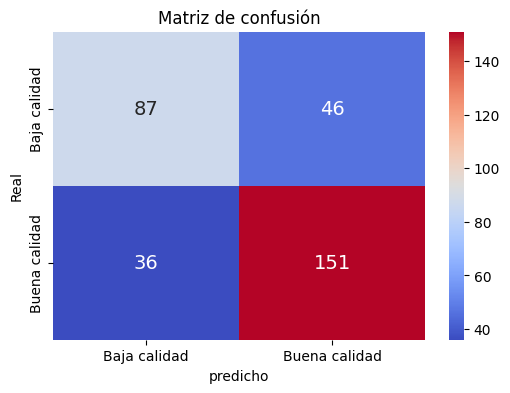

Cantidad de centros: 15
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.584375


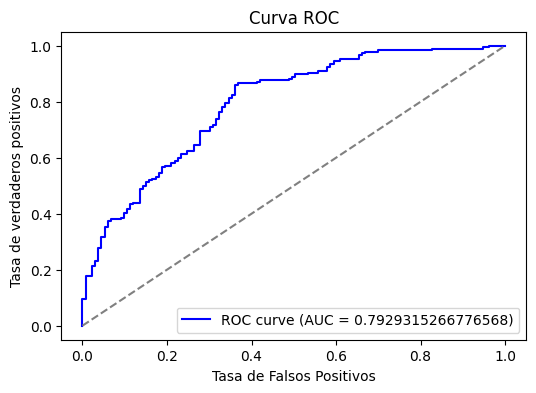

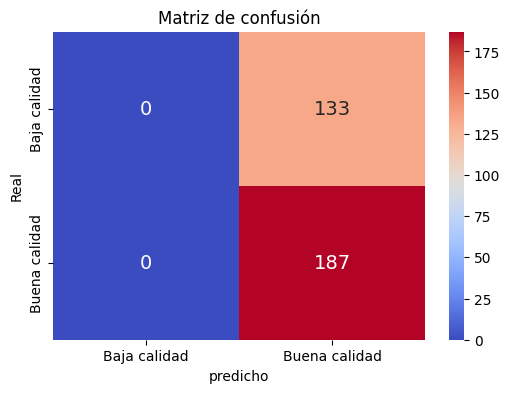

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.58125


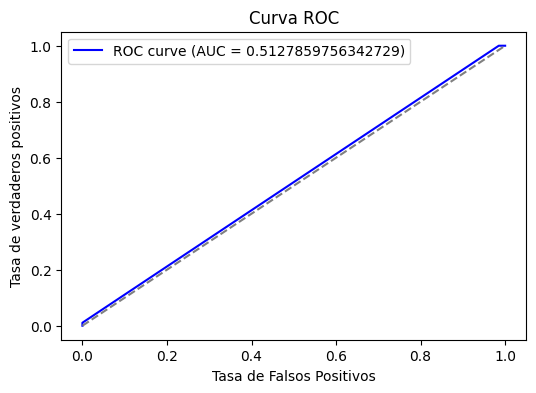

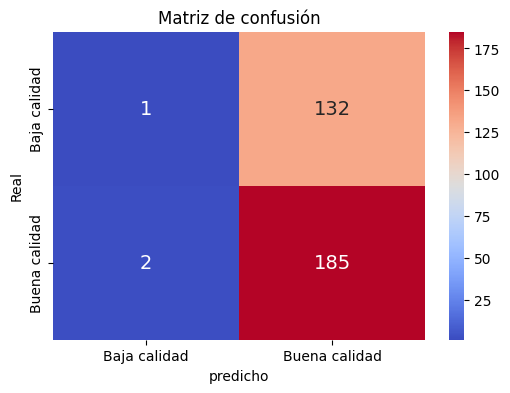

Valor de sigma: 2.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 0 0 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 0 1 0 0 1 0 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 0
 0 0 0 0 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.74375


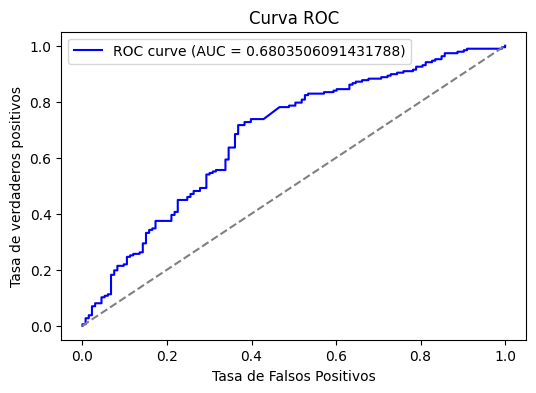

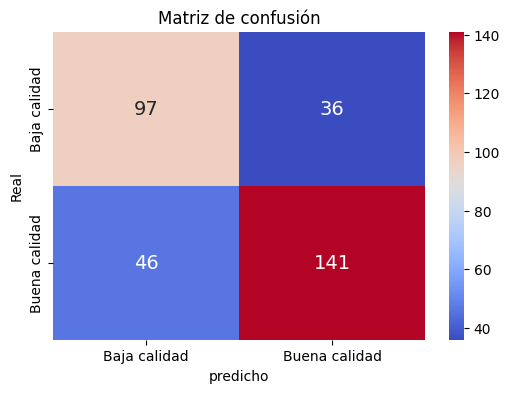

Valor de sigma: 5.0
Valores de predicción para y:
[0 0 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0
 1 1 0 0 0 1 0 0 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 0 1
 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.74375


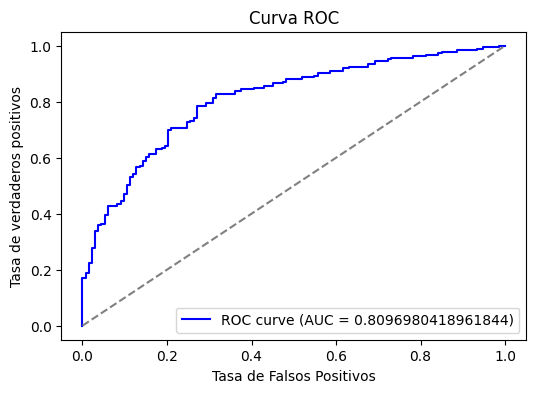

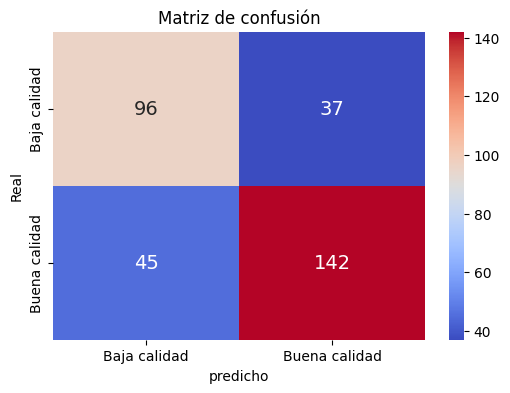

Cantidad de centros: 20
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1]
Precisión del modelo: 0.59375


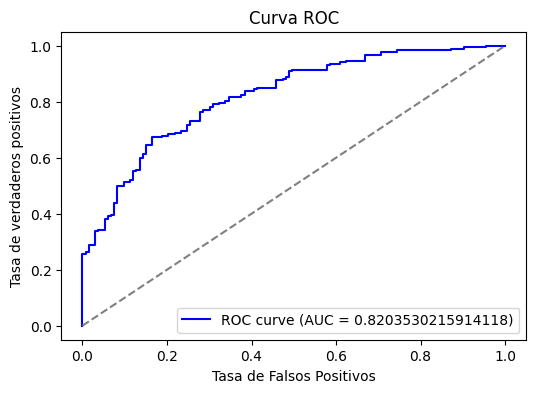

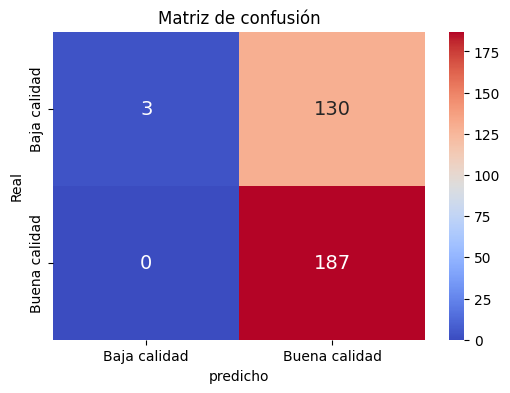

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.5875


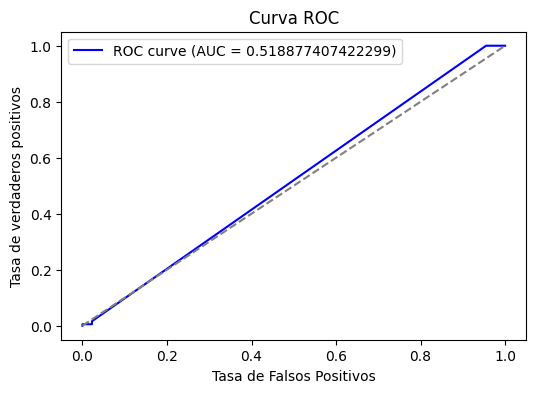

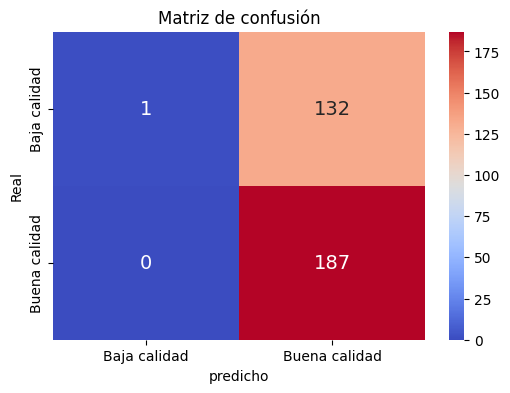

Valor de sigma: 2.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 0 1 0 1 1 0 1 0 1 0 1 1 0 0 1
 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 1 0 1 1 1 1 0 1 0 1 1 1 1 1
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 0 1 1 0
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 1 0
 1 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 0 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.759375


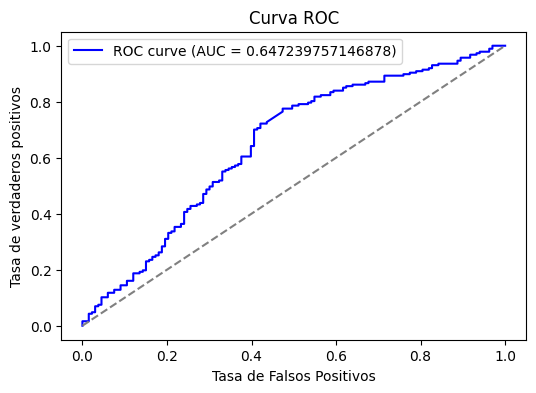

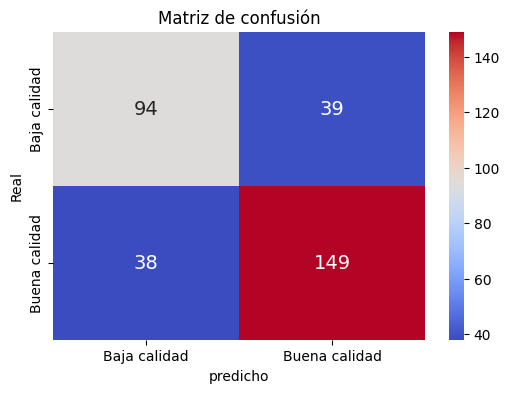

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 1 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 1 0
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.753125


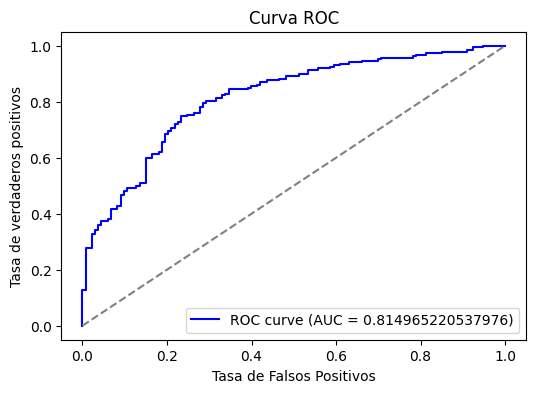

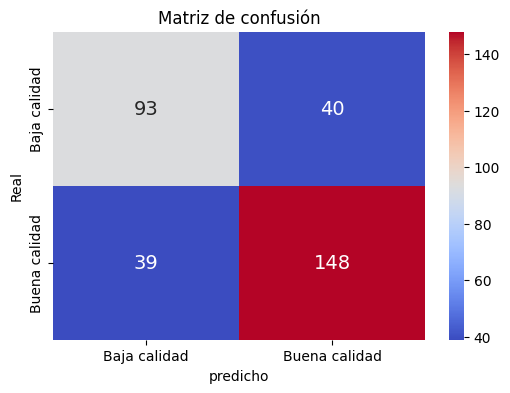

Cantidad de centros: 25
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.584375


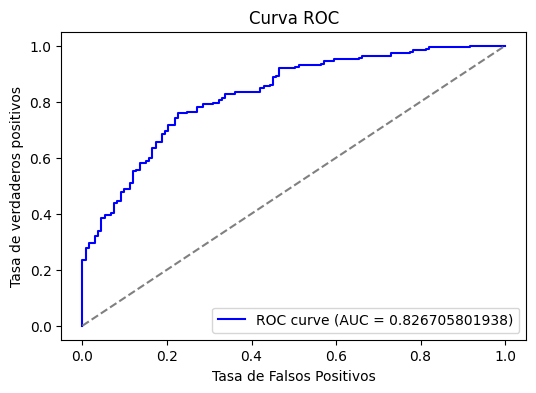

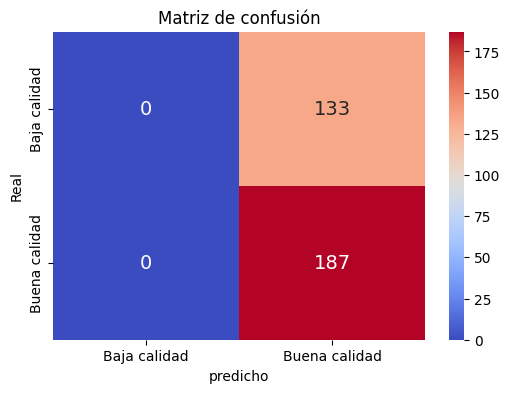

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1]
Precisión del modelo: 0.5875


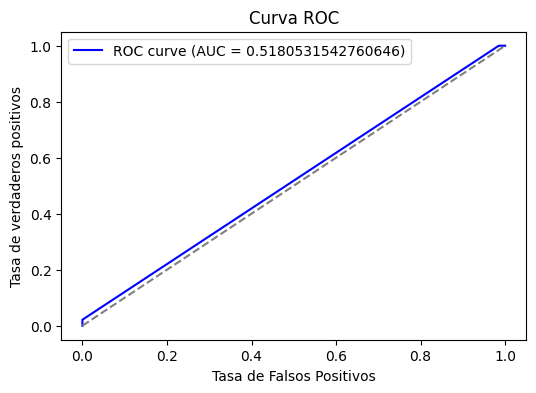

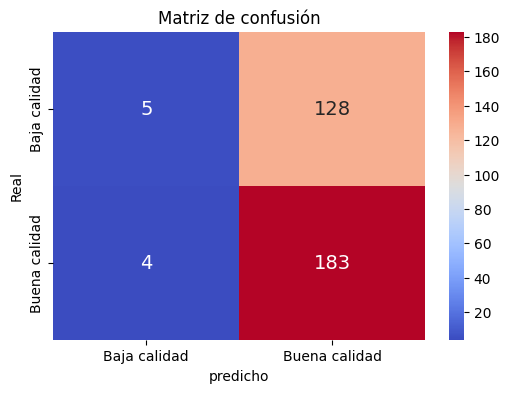

Valor de sigma: 2.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 1 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 0 0 0 1 1 0 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1 0 1 0 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1
 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 1 0 0 1]
Precisión del modelo: 0.7625


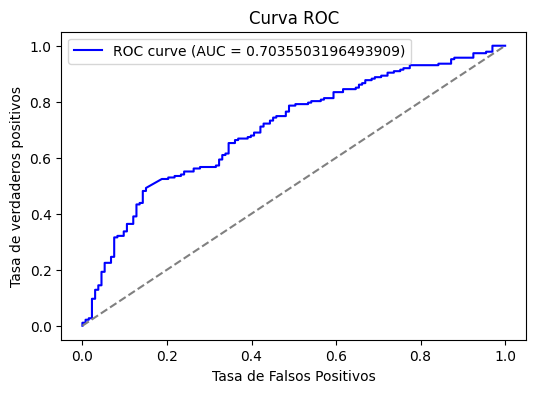

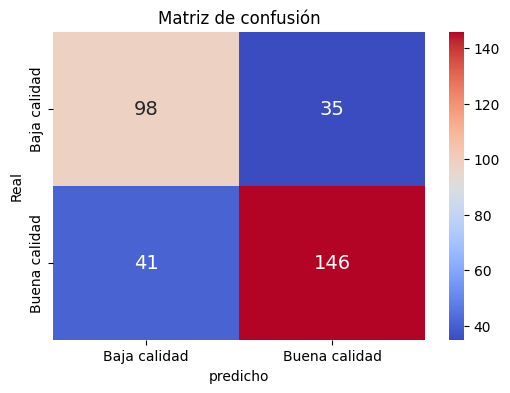

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 1 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1
 0 0 0 1 0 1 1 0 0 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.75625


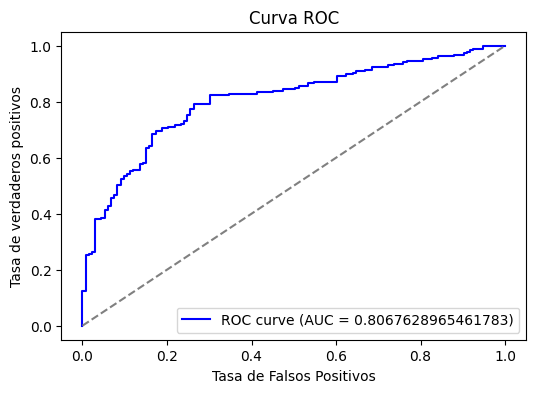

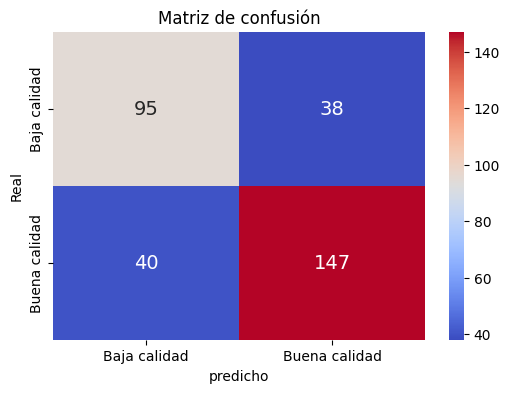

Cantidad de centros: 30
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.584375


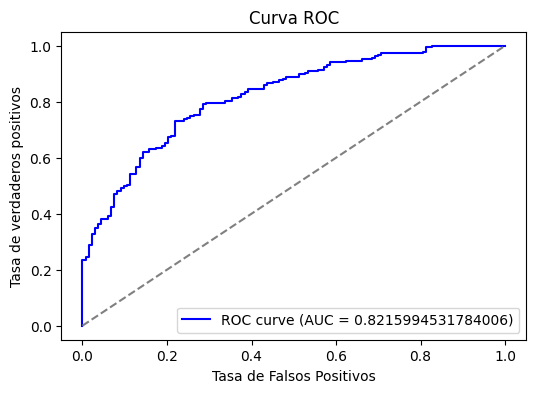

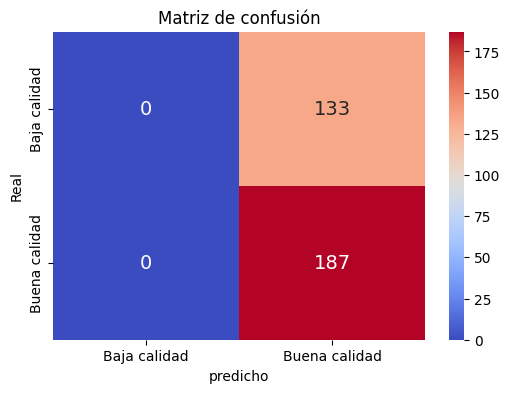

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.584375


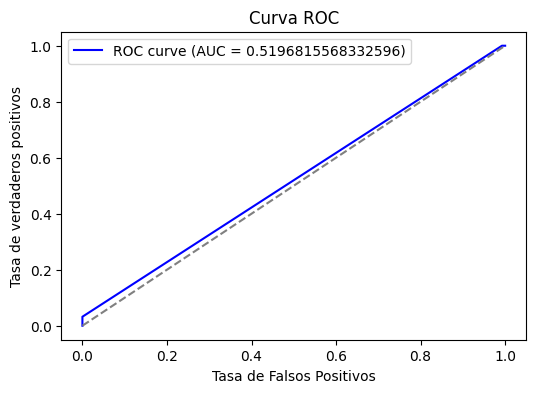

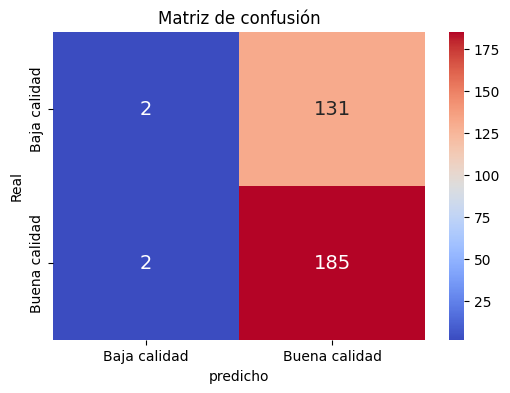

Valor de sigma: 2.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 0 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 0 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 0 1 0 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 1 0
 1 1 0 1 1 0 1 0 0 0 1 1 0 1 1 0 0 0 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 0 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.753125


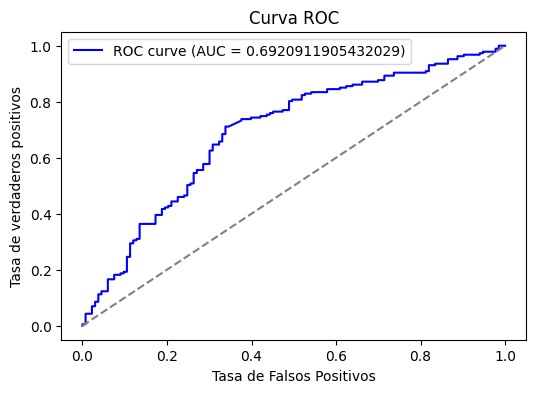

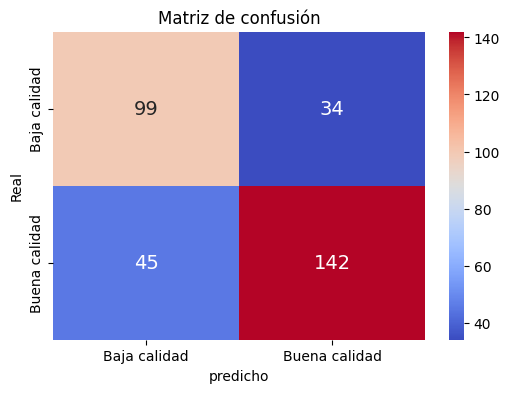

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1
 0 1 1 1 0 1 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1
 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1
 0 0 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 1]
Precisión del modelo: 0.75


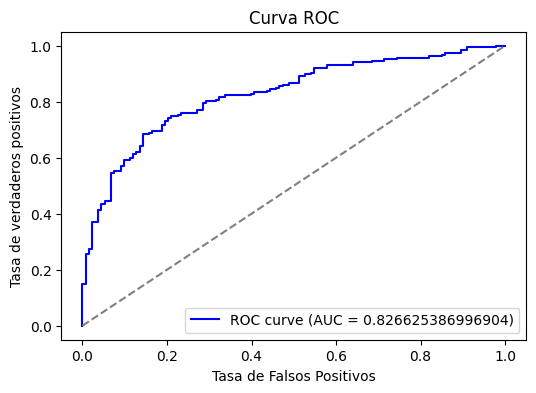

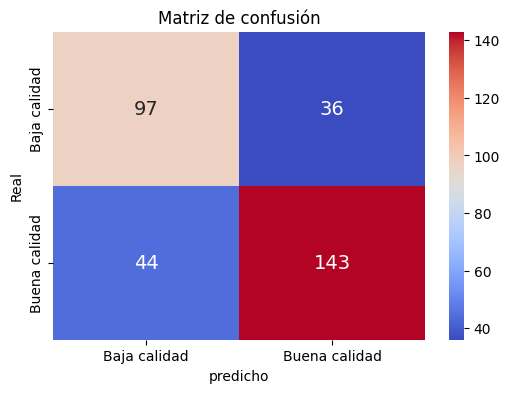

Tamaño del conjunto de prueba: 0.1
Cantidad de centros: 5
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.63125


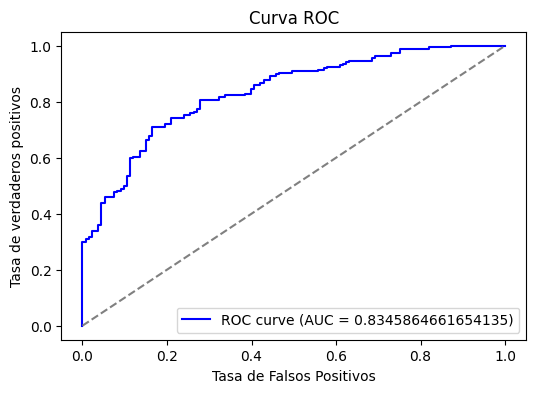

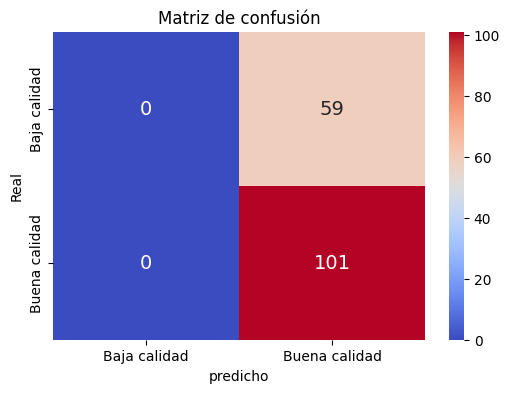

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.63125


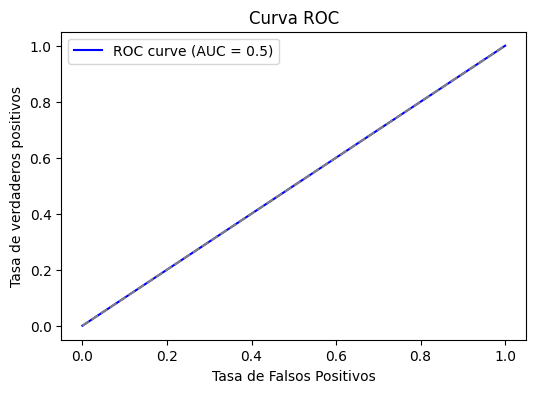

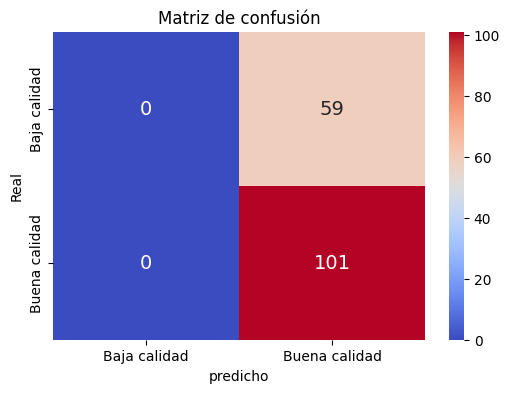

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 0 1 0 0 0 1 0 0 0 1 1 1 0 1 0 1 0 0 1 0 0 1
 0 1 0 0 1 1 0 0 0 0 0 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1
 0 1 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 1 0 1 0 1 0
 0 0 0 0 0 0 1 0 1 0 1 1 0 1 1 0 0 1 1 1 0 1 1 1 0 0 0 1 0 0 1 0 1 0 1 1 0
 1 0 0 1 0 1 1 0 0 1 1 1]
Precisión del modelo: 0.58125


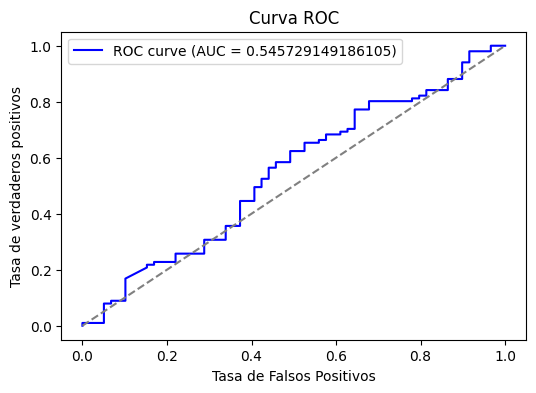

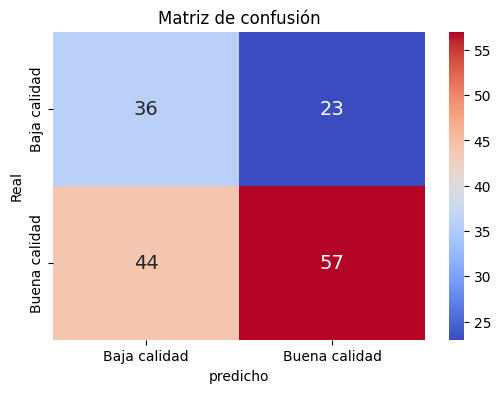

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 0 1
 0 1 0 0 1 1 1 0 0 1 0 1 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 0 0 0 1 1 1 1
 0 1 1 1 0 1 0 1 1 0 0 1 1 0 1 0 1 0 0 0 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 1 1
 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 1 1 1 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0
 1 0 0 1 0 1 0 1 0 1 1 1]
Precisión del modelo: 0.61875


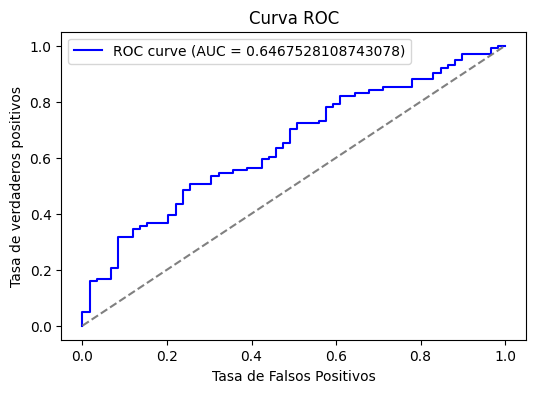

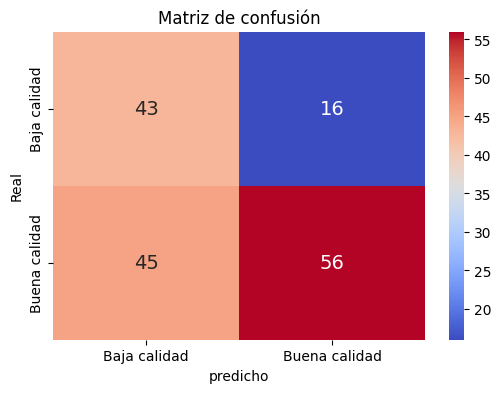

Cantidad de centros: 15
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.63125


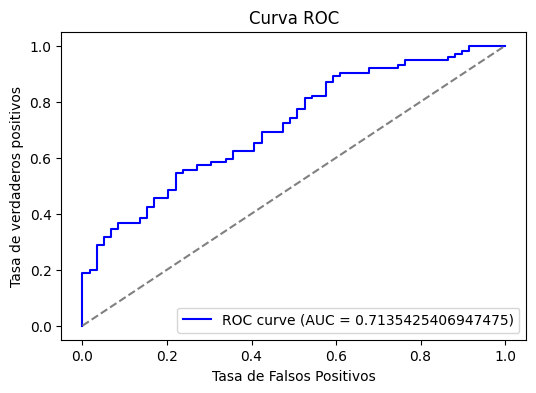

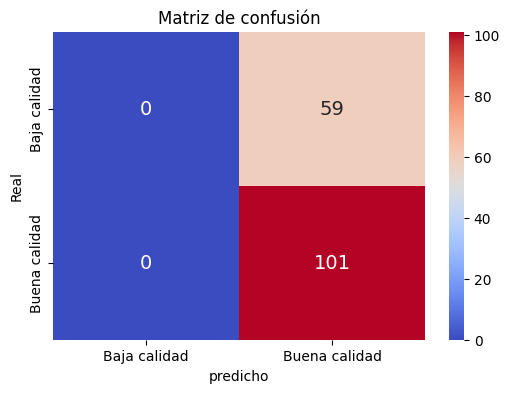

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.65


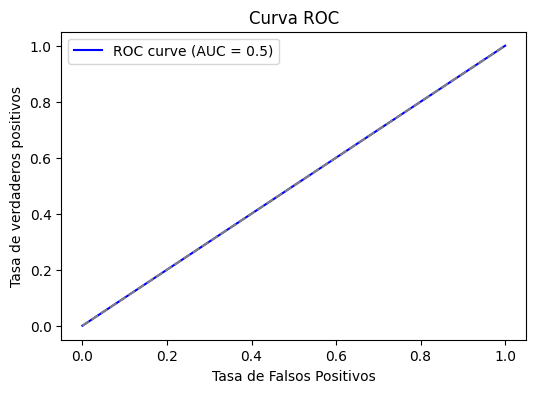

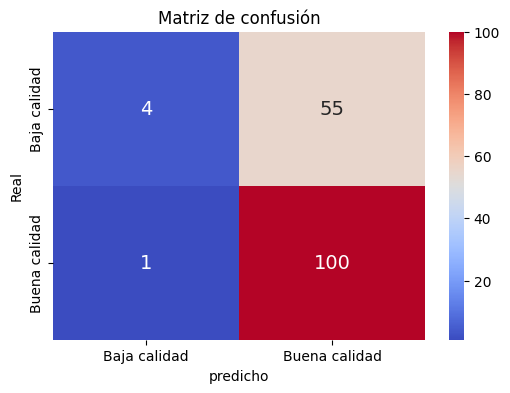

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 0 0 1 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 0 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 0 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.69375


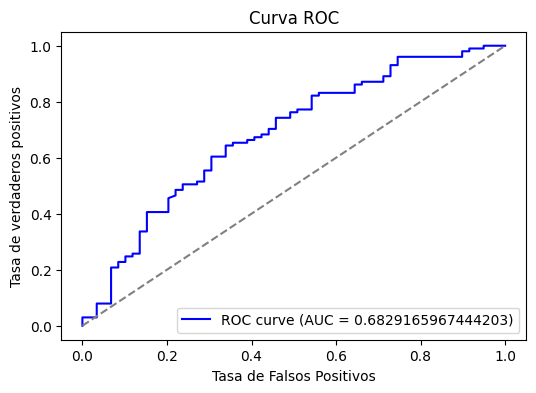

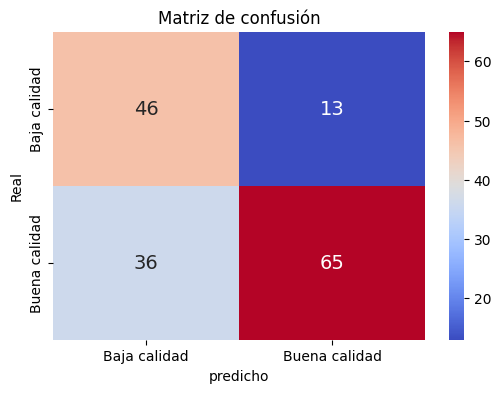

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 0 0 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 0 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0
 1 1 0 0 0 1 0 1 0 1 1 1]
Precisión del modelo: 0.6875


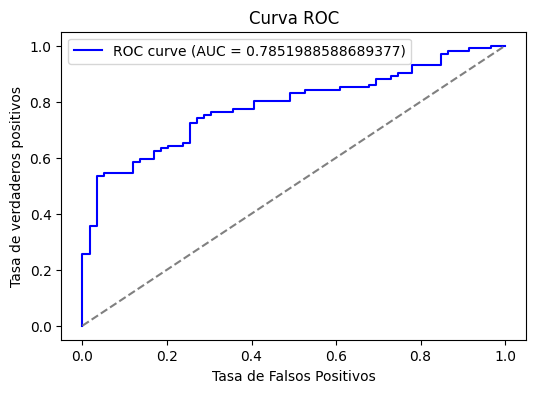

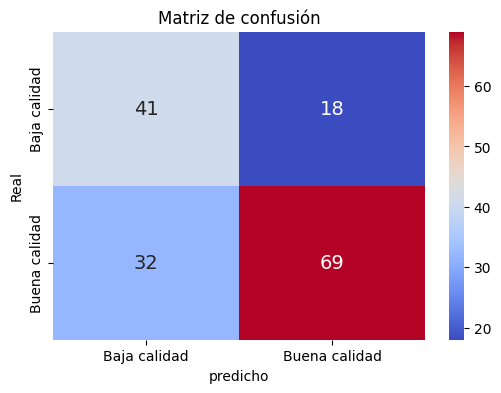

Cantidad de centros: 20
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.63125


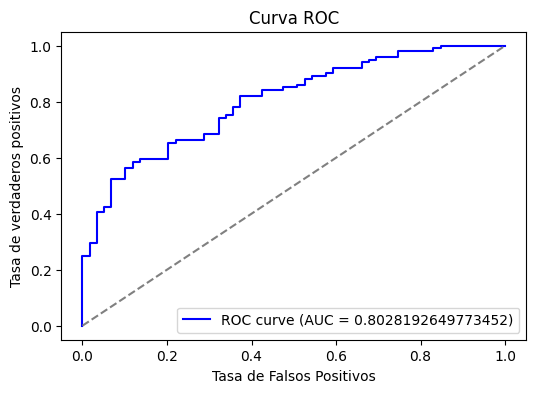

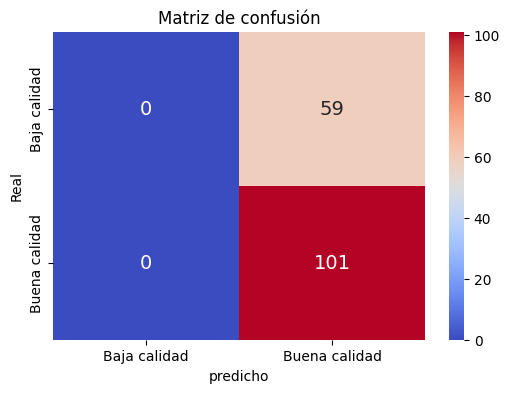

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.6375


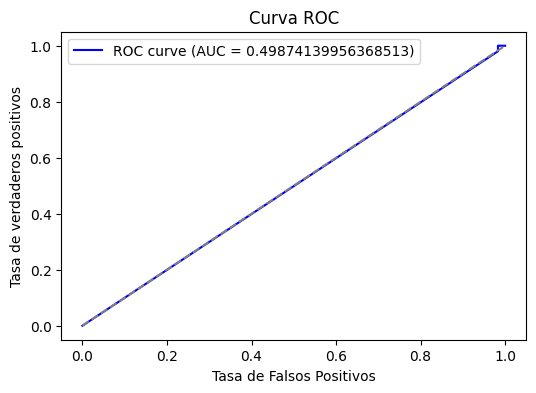

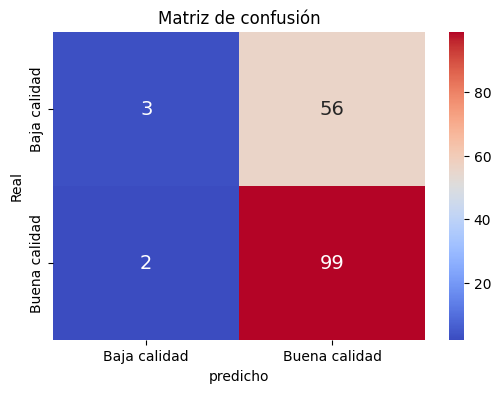

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 0 0 1
 0 1 1 0 0 0 1 0 0 0 0 0 1 1 1 0 0 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.725


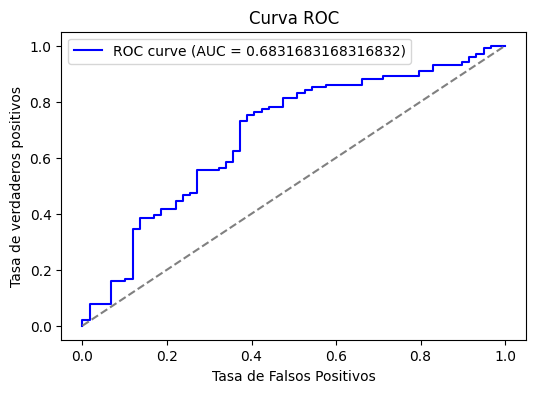

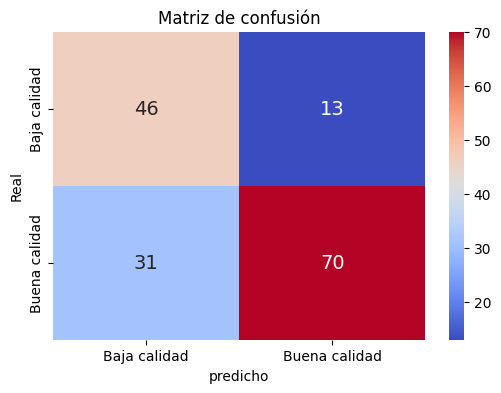

Valor de sigma: 5.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 0 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0
 1 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.7125


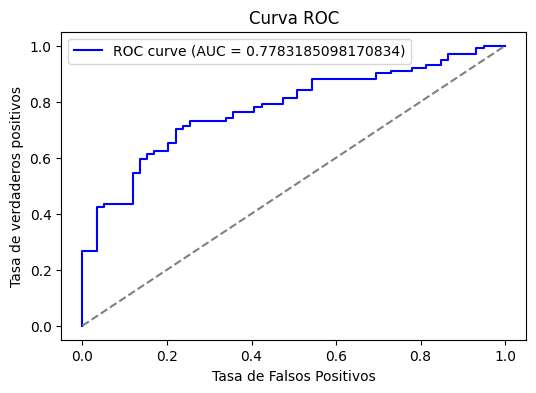

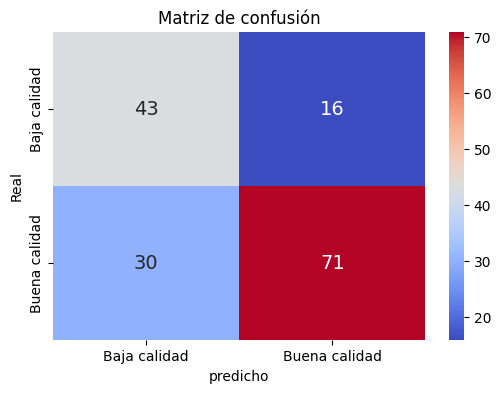

Cantidad de centros: 25
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.6375


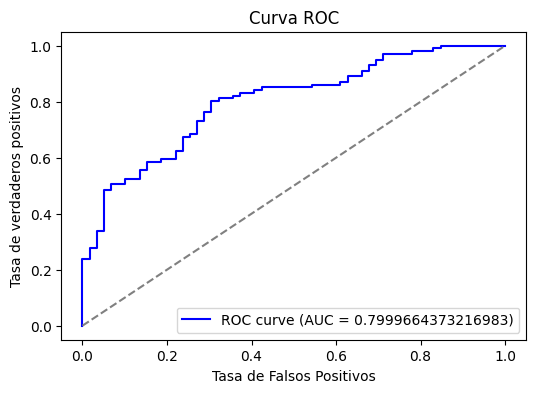

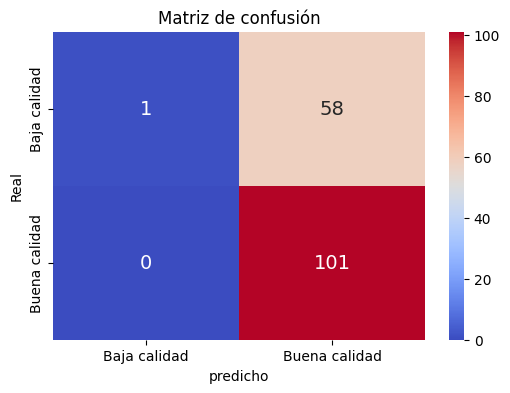

Valor de sigma: 0.5
Valores de predicción para y:
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.625


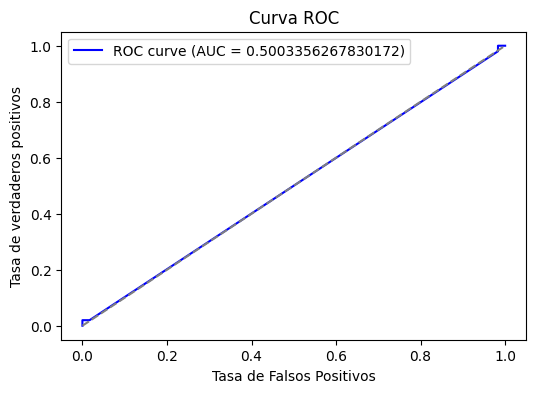

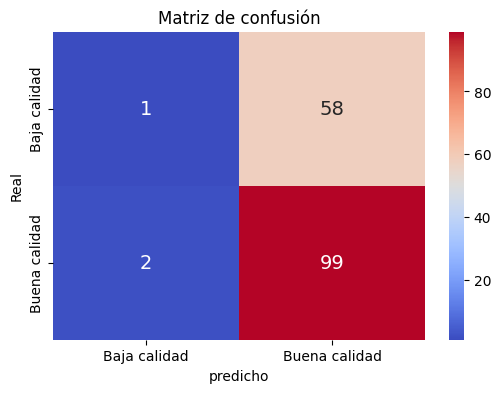

Valor de sigma: 2.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.725


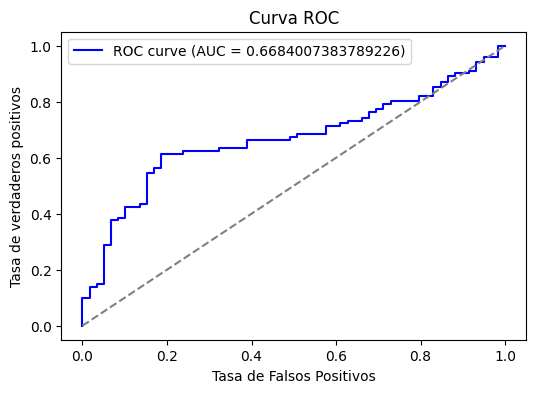

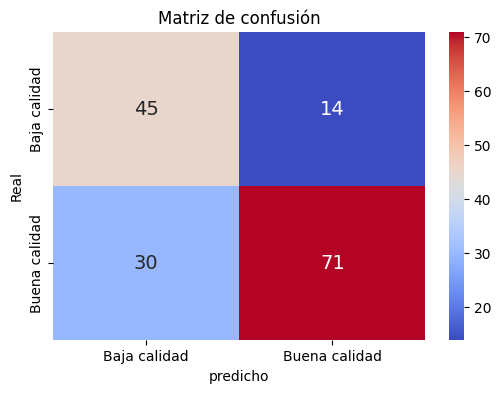

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.7375


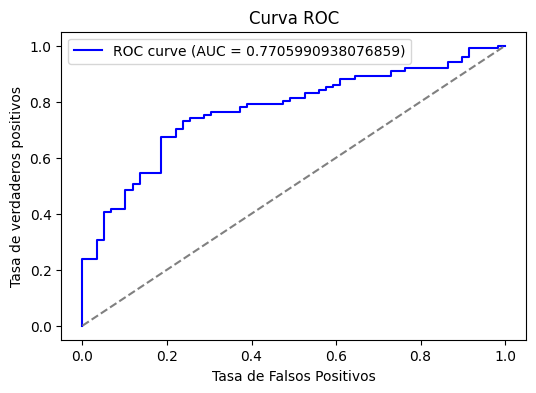

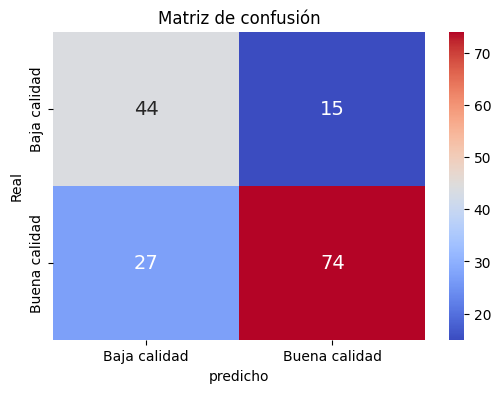

Cantidad de centros: 30
Valor de sigma: 0.1
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.63125


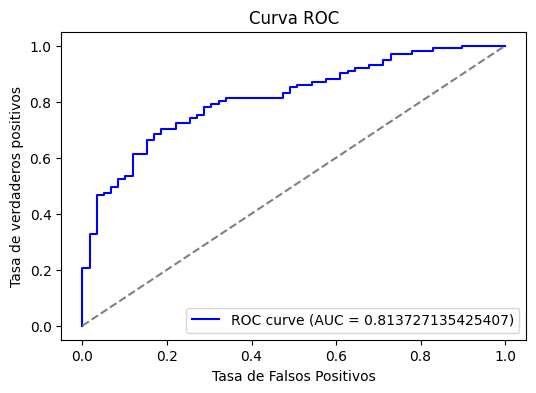

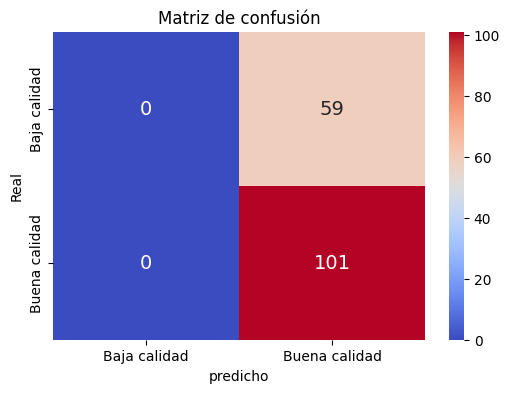

Valor de sigma: 0.5
Valores de predicción para y:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]
Precisión del modelo: 0.61875


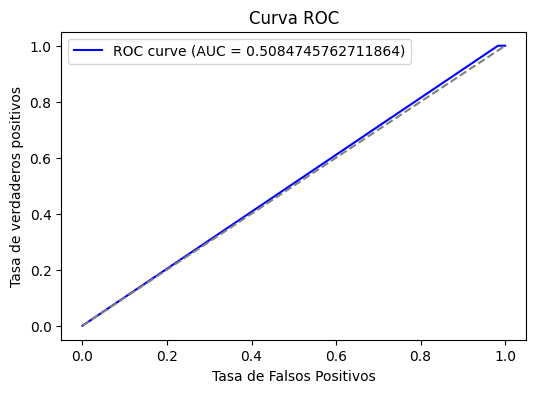

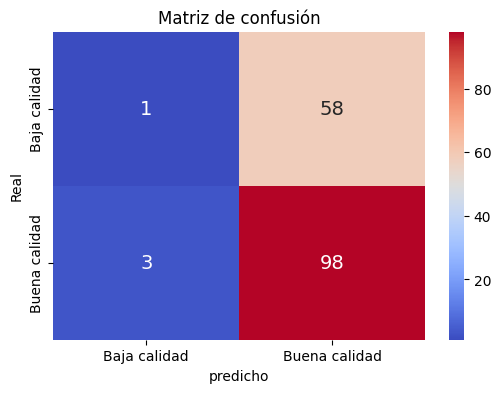

Valor de sigma: 2.0
Valores de predicción para y:
[1 1 1 0 1 1 1 1 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 0 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0
 0 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.75625


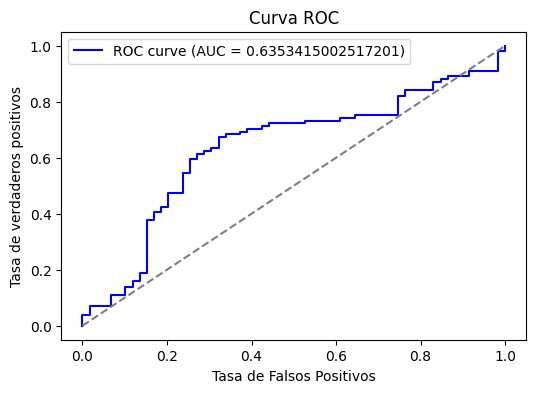

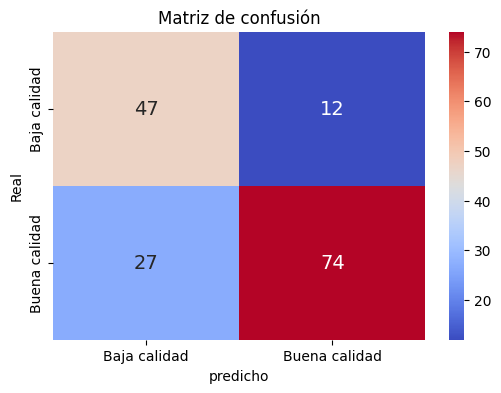

Valor de sigma: 5.0
Valores de predicción para y:
[0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 0 0 1
 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0
 1 1 0 0 0 1 0 0 0 0 1 1]
Precisión del modelo: 0.73125


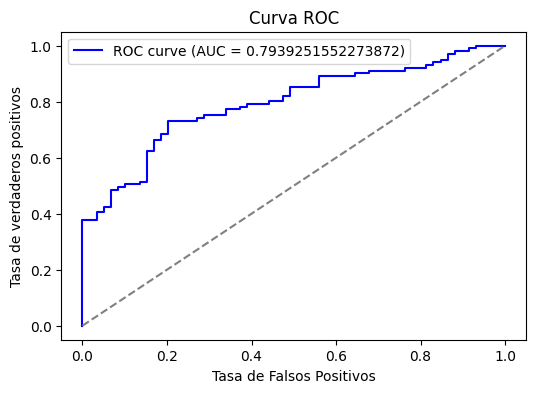

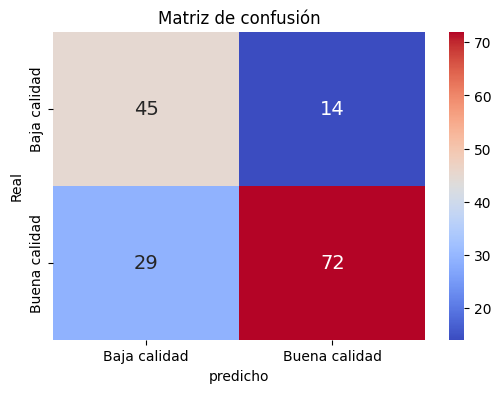

Mayor precisión: 0.7625
Con la combinación: {'test_size': 0.2, 'centros': 20, 'sigma': 2.0}
Mayor AUC: 0.8329379598729444
Con la combinación: {'test_size': 0.2, 'centros': 20, 'sigma': 5.0}


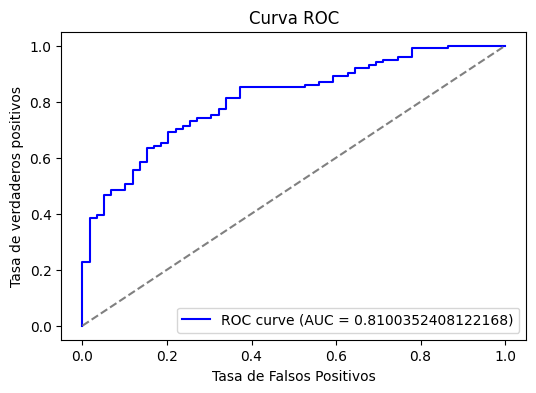

In [12]:
mejor_acc, parametros_acc, mejor_auc, parametros_auc = combinaciones(X, y)
print(f"Mayor precisión: {mejor_acc:}")
print(f"Con la combinación: {parametros_acc}")
print(f"Mayor AUC: {mejor_auc:}")
print(f"Con la combinación: {parametros_auc}")

# Conclusión
Para concluir, se obtuvó que la mejor precisión fue del 76% utilizando 20% como tamaño de prueba y 80% entrenamiento, además el valor de centro es 20, y el valor de sigm es igual a 2. Mientras que, el mejor valor de AUC fue 83% con el mismo tamaño de conjuntos, es decir, 20% prueba y 80% entrenamiento, además de centro igual a 20, pero en este caso sigma es igual a 5.   
Sin embargo, hay muchas combinaciones que generan muy poca precisión del modelo, o valores de AUC que significan que se esta clasificando de manera aleatoria, además de variass matrices de confusión con errores. Por lo que, es importante determinar de manera adecuada los paramétros e hiperparamétros al momento de entrenar un modelo de machine learning.
